# Results overview (3.1 – 3.6)

Recomputes every table and figure in the paper's Results section **directly from the saved result files** (no hard-coded numbers → re-running the experiments updates this notebook as is).

| Section | Content | Input files |
|---|---|---|
| 3.1 | Datasets | `data/cv_datasets` |
| 3.2 | Domain gap characterisation (P(x) vs label correspondence) | `benchmark/results/phase_01~05`, `results/nn_label_correspondence` |
| 3.3 | Target-only baseline (frozen / fine-tune) | `results/significance`, `results/finetune` |
| 3.4 | Five distribution-based DA methods | `results/comparison/best_performance.json`, `results/significance` |
| 3.5 | Label-based transfer (in vitro pretraining → fine-tune) | `results/pretrain_ft` |
| 3.6 | Synthesis: endpoint × transfer route | all of the above |
| 3.7 | Caveats for interpretation | — |

Endpoints are always ordered by the hypothesised **mechanistic distance (f_u → CL → t½)**.

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel

ROOT = r'..'
CV_DIR = os.path.join(ROOT, 'data', 'cv_datasets')
BENCH = os.path.join(ROOT, 'benchmark', 'results')
RES = os.path.join(ROOT, 'results')

PROPS = ['fu', 'clearance', 'half_life']                 # ordered by mechanistic distance
LABEL = {'fu': 'f_u', 'clearance': 'CL', 'half_life': 't½'}
COLOR = {'fu': '#1a7f37', 'clearance': '#0969da', 'half_life': '#cf222e'}
DA_METHODS = ['MMD', 'CORAL', 'DANN', 'CDAN', 'Importance Weighting']
SEEDS_FT = [0, 1, 2]     # seeds used in 09 and 10
K = 4                    # number of unfrozen layers used in 10

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})


def holm(p):
    # Holm–Bonferroni correction (NaN skipped)
    p = np.asarray(p, float)
    adj, running = np.full_like(p, np.nan), 0.0
    ok = np.where(~np.isnan(p))[0]
    for rank, i in enumerate(ok[np.argsort(p[ok])]):
        running = max(running, min(1.0, (len(ok) - rank) * p[i]))
        adj[i] = running
    return adj


def load_json(path):
    with open(path) as f:
        return json.load(f)

## 3.1 Datasets

- source = in vitro (ChEMBL + Biogen), identical in every fold
- target = human in vivo, scaffold 5-fold (train+test of fold 0 = the whole target)
- source–target overlap removed when building the CV splits

In [2]:
rows = []
for p in PROPS:
    s = pd.read_csv(os.path.join(CV_DIR, 'fold_0', f'{p}_source.csv'), low_memory=False)
    t = pd.concat([pd.read_csv(os.path.join(CV_DIR, 'fold_0', f'{p}_target_{x}.csv')) for x in ('train', 'test')])
    ds = np.where(s['assay_id'].notna(), 'ChEMBL', 'Biogen')
    rows.append({
        'endpoint': LABEL[p],
        'source measurements': len(s),
        'source compounds': s['smiles'].nunique(),
        '  ChEMBL rows': int((ds == 'ChEMBL').sum()),
        '  Biogen rows': int((ds == 'Biogen').sum()),
        'target compounds': t['smiles'].nunique(),
        'source/target ratio': round(s['smiles'].nunique() / t['smiles'].nunique(), 1),
        'source∩target': len(set(s['smiles']) & set(t['smiles'])),
    })
table1 = pd.DataFrame(rows).set_index('endpoint')
table1

,source measurements,source compounds,ChEMBL rows,Biogen rows,target compounds,source/target ratio,source∩target
endpoint,,,,,,,
f_u,3783,3597,3783,0,353,10.2,0
CL,14387,13566,11300,3087,1027,13.2,0
t½,9204,8477,9204,0,1164,7.3,0


In [3]:
# Target train / test size per fold
fold_rows = []
for p in PROPS:
    for k in range(5):
        n_tr = len(pd.read_csv(os.path.join(CV_DIR, f'fold_{k}', f'{p}_target_train.csv')))
        n_te = len(pd.read_csv(os.path.join(CV_DIR, f'fold_{k}', f'{p}_target_test.csv')))
        fold_rows.append({'endpoint': LABEL[p], 'fold': k, 'train': n_tr, 'test': n_te})
pd.DataFrame(fold_rows).pivot(index='endpoint', columns='fold', values=['train', 'test'])

train                     test                    
fold         0    1    2    3    4    0    1    2    3    4
endpoint                                                   
CL         821  821  822  822  822  206  206  205  205  205
f_u        282  282  282  283  283   71   71   71   70   70
t½         931  931  931  931  932  233  233  233  233  232

## 3.2 Domain gap characterisation

### 3.2.1 Differences in the molecular distribution P(x) — nearly the same across endpoints

| Metric | Meaning | Source |
|---|---|---|
| mean Tanimoto | mean ECFP4 similarity of random source–target pairs (500×500 sample) | phase 02 |
| scaffold Jaccard | fraction of shared Murcko scaffolds | phase 02 |
| MMD (median σ) | difference between Graphormer embedding distributions, σ = median heuristic | phase 03 |
| sliced Wasserstein | difference between embedding distributions (100 random projections) | phase 03 |
| domain AUC | 5-fold AUC of classifiers separating source from target (LR, RF) | phase 05 |

In [4]:
p1 = load_json(os.path.join(BENCH, 'phase_01_preprocessing.json'))
p2 = load_json(os.path.join(BENCH, 'phase_02_inter_similarity.json'))
p2i = load_json(os.path.join(BENCH, 'phase_02_intra_similarity.json'))
p2s = load_json(os.path.join(BENCH, 'phase_02_scaffolds.json'))
p3 = load_json(os.path.join(BENCH, 'phase_03_representation_gap.json'))
p4 = load_json(os.path.join(BENCH, 'phase_04_label_correspondence.json'))
p5 = load_json(os.path.join(BENCH, 'phase_05_domain_discriminability.json'))

gap = pd.DataFrame({LABEL[p]: {
    'n source / target (phase 01)': f"{p1[p]['source']['final_rows']} / {p1[p]['target']['final_rows']}",
    'mean Tanimoto (source–target)': p2[p]['mean'],
    'mean Tanimoto (within source)': p2i[p]['source']['mean'],
    'mean Tanimoto (within target)': p2i[p]['target']['mean'],
    'scaffold Jaccard': p2s[p]['jaccard_index'],
    'MMD (σ=1, reference)': p3[p]['mmd_distance'],
    'MMD (median σ)': p3[p]['mmd_median_heuristic'],
    'median σ': p3[p]['sigma_median'],
    'sliced Wasserstein': p3[p]['sliced_wasserstein'],
    'domain AUC (LR)': p5[p]['lr_auc_mean'],
    'domain AUC (RF)': p5[p]['rf_auc_mean'],
} for p in PROPS})
gap.style.format(lambda v: f'{v:.3f}' if isinstance(v, float) else v)

,f_u,CL,t½
n source / target (phase 01),3783 / 353,14387 / 1027,9204 / 1164
mean Tanimoto (source–target),0.097,0.095,0.094
mean Tanimoto (within source),0.125,0.120,0.117
mean Tanimoto (within target),0.095,0.095,0.097
scaffold Jaccard,0.000,0.000,0.000
"MMD (σ=1, reference)",0.058,0.039,0.039
MMD (median σ),0.319,0.331,0.301
median σ,12.619,13.877,13.850
sliced Wasserstein,0.209,0.239,0.219
domain AUC (LR),0.930,0.957,0.957


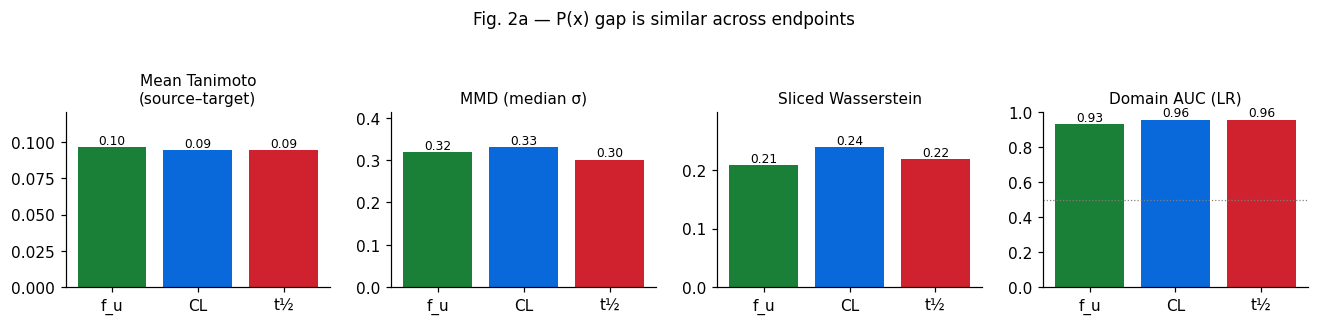

In [5]:
metrics = [('mean Tanimoto (source–target)', 'Mean Tanimoto\n(source–target)'),
           ('MMD (median σ)', 'MMD (median σ)'),
           ('sliced Wasserstein', 'Sliced Wasserstein'),
           ('domain AUC (LR)', 'Domain AUC (LR)')]
fig, axes = plt.subplots(1, 4, figsize=(12, 2.8))
for ax, (key, title) in zip(axes, metrics):
    vals = [gap.loc[key, LABEL[p]] for p in PROPS]
    ax.bar([LABEL[p] for p in PROPS], vals, color=[COLOR[p] for p in PROPS])
    ax.set_title(title, fontsize=10)
    ax.set_ylim(0, max(vals) * 1.25 if key != 'domain AUC (LR)' else 1.0)
    for i, v in enumerate(vals):
        ax.text(i, v, f'{v:.2f}', ha='center', va='bottom', fontsize=8)
axes[3].axhline(0.5, color='gray', lw=0.8, ls=':')
fig.suptitle('Fig. 2a — P(x) gap is similar across endpoints', fontsize=11, y=1.04)
plt.tight_layout()
plt.show()

### 3.2.2 Nearest-neighbour similarity distribution

For each target molecule, the Tanimoto similarity to its most similar source molecule (blue) and most similar other target molecule (orange). Same fingerprint (ECFP4, 2048 bit) and data (`normalized_data`, mean per molecule) as `11_nn_label_correspondence`.

In [6]:
from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import rdFingerprintGenerator
RDLogger.DisableLog('rdApp.*')
fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
NORM_DIR = os.path.join(ROOT, 'data', 'normalized_data')


def fps(smiles):
    out = []
    for s in smiles:
        m = Chem.MolFromSmiles(str(s))
        if m is not None:
            out.append(fpgen.GetFingerprint(m))
    return out


nn_sim = {}
for p in PROPS:
    S = fps(pd.read_csv(os.path.join(NORM_DIR, f'{p}_source.csv'), low_memory=False)['smiles'].unique())
    T = fps(pd.read_csv(os.path.join(NORM_DIR, f'{p}_target.csv'))['smiles'].unique())
    cross = np.array([max(DataStructs.BulkTanimotoSimilarity(f, S)) for f in T])
    within = []
    for i, f in enumerate(T):
        x = np.array(DataStructs.BulkTanimotoSimilarity(f, T))
        x[i] = -1
        within.append(x.max())
    nn_sim[p] = {'cross': cross, 'within': np.array(within)}

pd.DataFrame({LABEL[p]: {
    'n target': len(nn_sim[p]['cross']),
    'nearest source: median': np.median(nn_sim[p]['cross']),
    'nearest source: ≥0.4 (%)': 100 * np.mean(nn_sim[p]['cross'] >= 0.4),
    'nearest other target: median': np.median(nn_sim[p]['within']),
    'nearest other target: ≥0.4 (%)': 100 * np.mean(nn_sim[p]['within'] >= 0.4),
} for p in PROPS}).round(2)

,f_u,CL,t½
n target,353.00,1027.00,1164.00
nearest source: median,0.28,0.28,0.26
nearest source: ≥0.4 (%),24.08,13.53,10.74
nearest other target: median,0.29,0.44,0.46
nearest other target: ≥0.4 (%),33.43,54.33,58.76


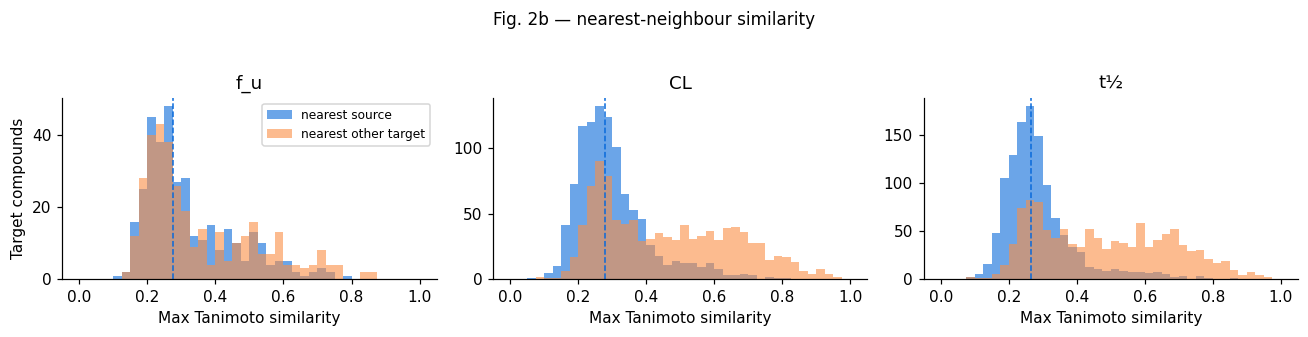

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 2.9), sharex=True)
for ax, p in zip(axes, PROPS):
    ax.hist(nn_sim[p]['cross'], bins=40, range=(0, 1), alpha=0.6, color='#0969da', label='nearest source')
    ax.hist(nn_sim[p]['within'], bins=40, range=(0, 1), alpha=0.6, color='#fb8f44', label='nearest other target')
    ax.axvline(np.median(nn_sim[p]['cross']), color='#0969da', lw=1, ls='--')
    ax.set_title(LABEL[p])
    ax.set_xlabel('Max Tanimoto similarity')
axes[0].set_ylabel('Target compounds')
axes[0].legend(fontsize=8)
fig.suptitle('Fig. 2b — nearest-neighbour similarity', fontsize=11, y=1.04)
plt.tight_layout()
plt.show()

### 3.2.3 Label correspondence (P(y|x)) — differs by endpoint

Spearman ρ between the target label and the nearest neighbour's label for structurally similar pairs (Tanimoto ≥ threshold).
- **cross** = in vitro neighbour, **within** = another in vivo neighbour (upper-bound reference), **null** = 95th percentile |ρ| under source-label permutation
- **rel** = cross ρ / within ρ (1 means an in vitro neighbour is as informative as an in vivo neighbour)
- representative threshold = 0.4 (≥ 85 pairs for all three endpoints)

In [8]:
nn_rows = []
for p in PROPS:
    for t, d in p4[p]['by_threshold'].items():
        nn_rows.append({'endpoint': LABEL[p], 'threshold': float(t), 'n pairs': d['n_pairs'],
                        'cross ρ': d['spearman_rho'],
                        '95% CI': None if d['spearman_rho'] is None else f"[{d['rho_ci'][0]:.2f}, {d['rho_ci'][1]:.2f}]",
                        'null 95%': d['null_rho_95'], 'above null': d['above_null'],
                        'within ρ': d['within_target_rho'], 'rel': d['relative_to_within']})
nn_table = pd.DataFrame(nn_rows)
nn_table[nn_table['n pairs'] >= 10].set_index(['endpoint', 'threshold']).round(3)

n pairs  cross ρ         95% CI  null 95%  above null  within ρ    rel
endpoint threshold                                                                        
f_u      0.3            153    0.576   [0.44, 0.70]     0.147        True     0.619  0.929
         0.4             85    0.699   [0.55, 0.83]     0.213        True     0.637  1.097
         0.5             48    0.799   [0.61, 0.92]     0.286        True     0.602  1.328
         0.6             16    0.828   [0.50, 0.98]     0.509        True     0.636  1.303
CL       0.3            407    0.111   [0.01, 0.21]     0.084        True     0.477  0.232
         0.4            139    0.193   [0.02, 0.35]     0.170        True     0.468  0.412
         0.5             70    0.352   [0.14, 0.54]     0.249        True     0.511  0.689
         0.6             27    0.502   [0.09, 0.76]     0.355        True     0.514  0.977
t½       0.3            371    0.008  [-0.09, 0.11]     0.122       False     0.509  0.016
         0.4            125    0.047  [-0.13, 0.23]     0.182       False     0.547  0.086
         0.5             64    0.095  [-0.17, 0.33]     0.248       False     0.575  0.165
         0.6             30    0.099  [-0.28, 0.47]     0.398       False     0.618  0.160

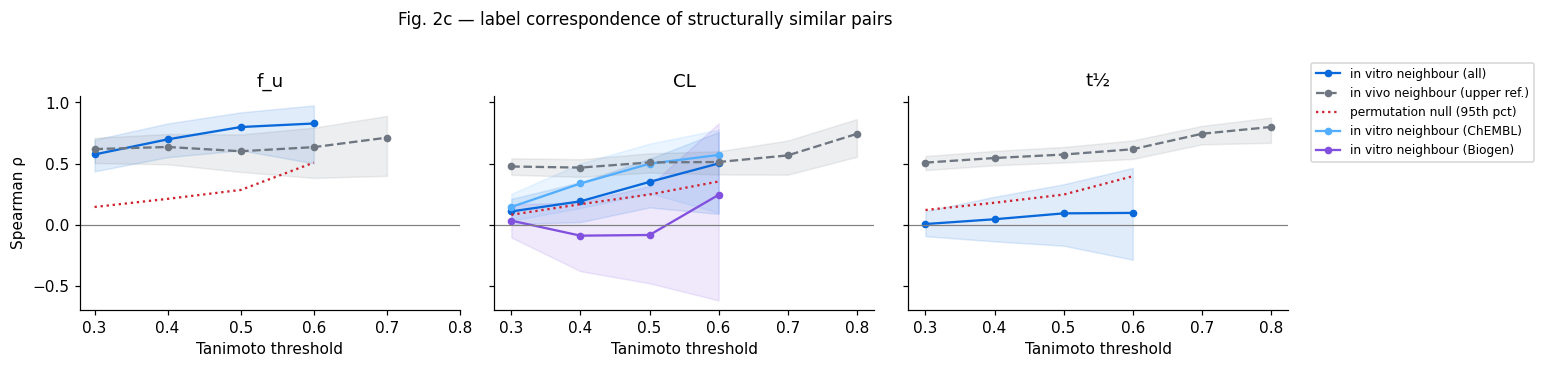

In [9]:
nn_csv = pd.read_csv(os.path.join(RES, 'nn_label_correspondence', 'nn_label_correlation.csv'))
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)
for ax, p in zip(axes, PROPS):
    r = nn_csv[nn_csv['property'] == p]
    for (kind, ds), color, ls, lab in [(('cross', 'all'), '#0969da', '-', 'in vitro neighbour (all)'),
                                        (('cross', 'ChEMBL'), '#54aeff', '-', 'in vitro neighbour (ChEMBL)'),
                                        (('cross', 'Biogen'), '#8250df', '-', 'in vitro neighbour (Biogen)'),
                                        (('within_target', '-'), '#6e7781', '--', 'in vivo neighbour (upper ref.)')]:
        q = r[(r['kind'] == kind) & (r['source_set'] == ds)].dropna(subset=['spearman_rho'])
        if q.empty:
            continue
        ax.plot(q['threshold'], q['spearman_rho'], marker='o', ms=4, color=color, ls=ls, label=lab)
        ax.fill_between(q['threshold'], q['rho_lo'], q['rho_hi'], color=color, alpha=0.12)
    q = r[(r['kind'] == 'cross') & (r['source_set'] == 'all')].dropna(subset=['null_rho_95'])
    ax.plot(q['threshold'], q['null_rho_95'], color='#cf222e', ls=':', label='permutation null (95th pct)')
    ax.axhline(0, color='gray', lw=0.8)
    ax.set_xticks(sorted(nn_csv['threshold'].unique()))
    ax.set_title(LABEL[p])
    ax.set_xlabel('Tanimoto threshold')
axes[0].set_ylabel('Spearman ρ')
legend = {}
for ax in axes:
    for h, l in zip(*ax.get_legend_handles_labels()):
        legend.setdefault(l, h)
fig.legend(legend.values(), legend.keys(), bbox_to_anchor=(1.0, 0.9), loc='upper left', fontsize=8)
fig.suptitle('Fig. 2c — label correspondence of structurally similar pairs', fontsize=11, y=1.03)
plt.tight_layout()
plt.show()

## 3.3 Target-only baseline

- **frozen**: fixed Graphormer embedding + MLP (`01`; multi-seed is the Baseline of `08`, 10 seeds)
- **target-only FT**: fine-tuning the top k Graphormer layers on the target only (`09`, seeds 0–2)
- test: per-fold seed mean → paired t-test against frozen (n = 5 folds), matched by seed

In [10]:
# Use the re-run results that also store MAE (significance_mae) if present
SIG_DIR = os.path.join(RES, 'significance_mae') if os.path.exists(os.path.join(RES, 'significance_mae', 'summary.csv')) else os.path.join(RES, 'significance')
print('multi-seed results:', SIG_DIR)
sig_runs = pd.read_csv(os.path.join(SIG_DIR, 'runs.csv'))
base = sig_runs[sig_runs['method'] == 'Baseline']
per_seed = base.groupby(['property', 'seed'])[['r2', 'rho']].mean()   # 5-fold mean per seed
pd.DataFrame({LABEL[p]: {
    'R² (mean over 10 seeds × 5 folds)': base[base['property'] == p]['r2'].mean(),
    'R² seed-to-seed SD': per_seed.loc[p]['r2'].std(),
    'ρ': base[base['property'] == p]['rho'].mean(),
    'RMSE': base[base['property'] == p]['rmse'].mean(),
} for p in PROPS}).round(3)

multi-seed results: ..\results\significance_mae


,f_u,CL,t½
R² (mean over 10 seeds × 5 folds),0.252,0.097,0.084
R² seed-to-seed SD,0.020,0.014,0.024
ρ,0.584,0.365,0.399
RMSE,0.844,0.948,0.948


In [11]:
ft = pd.read_csv(os.path.join(RES, 'finetune', 'runs.csv'))
frozen3 = base[base['seed'].isin(SEEDS_FT)]
rows = []
for p in PROPS:
    fz = frozen3[frozen3['property'] == p].groupby('fold')['r2'].mean()
    rows.append({'endpoint': LABEL[p], 'model': 'frozen (seed 0–2)', 'R²': fz.mean()})
    for k in sorted(ft['k'].unique()):
        m = ft[(ft['property'] == p) & (ft['k'] == k) & ft['seed'].isin(SEEDS_FT)].groupby('fold')['r2'].mean()
        rows.append({'endpoint': LABEL[p], 'model': f'target-only FT k={k}', 'R²': m.mean(),
                     'ΔR² vs frozen': (m - fz).mean(), 'p': ttest_rel(m, fz).pvalue})
ft_table = pd.DataFrame(rows)
ft_table['p (Holm, 9 comparisons)'] = holm(ft_table['p'])
ft_table.set_index(['endpoint', 'model']).round(4)

R²  ΔR² vs frozen       p  p (Holm, 9 comparisons)
endpoint model                                                                     
f_u      frozen (seed 0–2)   0.2485            NaN     NaN                      NaN
         target-only FT k=1  0.2427        -0.0058  0.8113                      1.0
         target-only FT k=2  0.2556         0.0071  0.7658                      1.0
         target-only FT k=4  0.2788         0.0303  0.3465                      1.0
CL       frozen (seed 0–2)   0.0999            NaN     NaN                      NaN
         target-only FT k=1  0.1032         0.0033  0.8413                      1.0
         target-only FT k=2  0.0956        -0.0043  0.8134                      1.0
         target-only FT k=4  0.0898        -0.0101  0.6808                      1.0
t½       frozen (seed 0–2)   0.1067            NaN     NaN                      NaN
         target-only FT k=1  0.0938        -0.0129  0.1970                      1.0
         target-only FT k=2  0.0806        -0.0261  0.2964                      1.0
         target-only FT k=4  0.1131         0.0064  0.7533                      1.0

## 3.4 Distribution-based DA

- methods: MMD, CORAL, DANN, CDAN (regression variant), Importance Weighting
- λ ∈ {0.01, 0.05, 0.1, 0.3, 0.5, 1.0} chosen by maximum 5-fold mean **val R²** (`07`)
- re-run with the chosen λ for 10 seeds × 5 folds (`08`), per-fold seed mean → paired t-test against the baseline, Holm correction over 15 comparisons
- MMD, CORAL, DANN and CDAN use **only source features** (no source labels); only IW uses source labels

In [12]:
best = load_json(os.path.join(RES, 'comparison', 'best_performance.json'))
pd.DataFrame({LABEL[p]: {m: best[p][m]['best_weight'] for m in DA_METHODS} for p in PROPS}).rename_axis('selected λ')

,f_u,CL,t½
selected λ,,,
MMD,1.0,0.10,0.05
CORAL,0.3,0.01,0.50
DANN,0.1,0.01,0.05
CDAN,0.3,0.50,0.01
Importance Weighting,1.0,1.00,0.01


In [13]:
sig = pd.read_csv(os.path.join(SIG_DIR, 'summary.csv'))
da_table = sig[sig['method'] != 'Baseline'].copy()
da_table['endpoint'] = da_table['property'].map(LABEL)
da_table = da_table.set_index(['endpoint', 'method']).loc[[LABEL[p] for p in PROPS]]
da_table[['lambda', 'r2_mean', 'delta_r2', 'delta_rho', 'p_ttest', 'p_wilcoxon', 'p_holm', 'win_rate']].round(4)

lambda  r2_mean  delta_r2  delta_rho  p_ttest  p_wilcoxon  p_holm  win_rate
endpoint method                                                                                           
f_u      MMD                     1.00   0.2364   -0.0158    -0.0088   0.0816      0.1250     1.0      0.40
         CORAL                   0.30   0.2508   -0.0014    -0.0007   0.9498      1.0000     1.0      0.50
         DANN                    0.10   0.2370   -0.0153    -0.0045   0.1000      0.1250     1.0      0.40
         CDAN                    0.30   0.2656    0.0134     0.0133   0.3932      0.4375     1.0      0.56
         Importance Weighting    1.00   0.2445   -0.0078     0.0046   0.6842      1.0000     1.0      0.44
CL       MMD                     0.10   0.0946   -0.0023    -0.0026   0.7195      0.8125     1.0      0.50
         CORAL                   0.01   0.0962   -0.0007    -0.0006   0.8759      0.8125     1.0      0.52
         DANN                    0.01   0.0901   -0.0068    -0.0048   0.4343      0.8125     1.0      0.48
         CDAN                    0.50   0.1062    0.0093     0.0015   0.2917      0.3125     1.0      0.64
         Importance Weighting    1.00   0.0984    0.0015    -0.0014   0.7876      1.0000     1.0      0.46
t½       MMD                     0.05   0.0835   -0.0004     0.0028   0.9712      1.0000     1.0      0.54
         CORAL                   0.50   0.0875    0.0037     0.0035   0.6378      0.8125     1.0      0.54
         DANN                    0.05   0.0834   -0.0004    -0.0001   0.8918      1.0000     1.0      0.50
         CDAN                    0.01   0.0855    0.0017     0.0006   0.7720      1.0000     1.0      0.62
         Importance Weighting    0.01   0.0888    0.0049    -0.0007   0.1449      0.3125     1.0      0.60

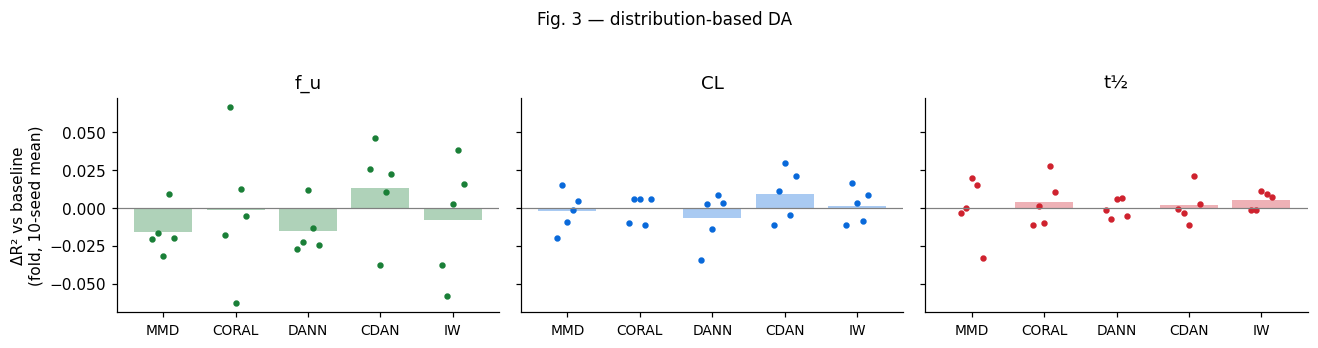

In [14]:
# Per-fold ΔR² (seed mean) points + mean bars
fig, axes = plt.subplots(1, 3, figsize=(12, 3.0), sharey=True)
for ax, p in zip(axes, PROPS):
    fm = sig_runs[sig_runs['property'] == p].groupby(['method', 'fold'])['r2'].mean().unstack('method')
    for i, m in enumerate(DA_METHODS):
        d = fm[m] - fm['Baseline']
        ax.bar(i, d.mean(), color=COLOR[p], alpha=0.35)
        ax.scatter(np.full(len(d), i) + np.linspace(-0.15, 0.15, len(d)), d, s=10, color=COLOR[p])
    ax.axhline(0, color='gray', lw=0.8)
    ax.set_xticks(range(len(DA_METHODS)))
    ax.set_xticklabels(['MMD', 'CORAL', 'DANN', 'CDAN', 'IW'], fontsize=9)
    ax.set_title(LABEL[p])
axes[0].set_ylabel('ΔR² vs baseline\n(fold, 10-seed mean)')
fig.suptitle('Fig. 3 — distribution-based DA', fontsize=11, y=1.04)
plt.tight_layout()
plt.show()

## 3.5 Label-based transfer (in vitro pretraining → fine-tuning)

- Stage 1: pretrain the top 4 Graphormer layers + head on in vitro labels (molecules overlapping the target excluded, early stopping on a source scaffold 90/10 val split)
- Stage 2: re-initialise the head → target fine-tuning (same conditions as 09, seeds 0–2)
- **zero-shot ρ**: Spearman ρ of the pretrained model applied directly to the target test set (how well in vitro predictions rank in vivo values)
- comparison: frozen / target-only FT (k=4) / pretrain → FT, matched by seed and fold

In [15]:
pre_log = pd.read_csv(os.path.join(RES, 'pretrain_ft', 'pretrain_log.csv'))
pre_log.assign(endpoint=pre_log['property'].map(LABEL)).groupby('endpoint')[['n_train', 'n_val', 'best_epoch', 'source_val_r2']].agg(['mean', 'min', 'max']).round(3)

n_train                 n_val             best_epoch         source_val_r2              
             mean    min    max    mean   min   max       mean min max          mean    min    max
endpoint                                                                                          
CL        12946.0  12946  12946  1440.0  1440  1440     15.000   9  19         0.328  0.314  0.341
f_u        3380.0   3380   3380   398.0   398   398     21.333  19  26         0.556  0.534  0.583
t½         8272.0   8272   8272   930.0   930   930     14.333  12  17         0.403  0.379  0.429

In [16]:
pre = pd.read_csv(os.path.join(RES, 'pretrain_ft', 'runs.csv'))
pre = pre[pre['seed'].isin(SEEDS_FT)]
ftk = ft[(ft['k'] == K) & ft['seed'].isin(SEEDS_FT)]

fold_r2 = {}
rows = []
for p in PROPS:
    fz = frozen3[frozen3['property'] == p].groupby('fold')['r2'].mean()
    tf = ftk[ftk['property'] == p].groupby('fold')['r2'].mean()
    pf = pre[pre['property'] == p].groupby('fold')['r2'].mean()
    fold_r2[p] = pd.DataFrame({'frozen': fz, f'target-only FT (k={K})': tf, 'pretrain → FT': pf})
    rows.append({
        'endpoint': LABEL[p],
        'frozen R²': fz.mean(), 'target-only FT R²': tf.mean(), 'pretrain→FT R²': pf.mean(),
        'ΔR² vs frozen': (pf - fz).mean(), 'p vs frozen': ttest_rel(pf, fz).pvalue,
        'ΔR² vs target-only FT': (pf - tf).mean(), 'p vs target-only FT': ttest_rel(pf, tf).pvalue,
        'relative gain vs frozen (%)': 100 * (pf - fz).mean() / fz.mean(),
        'pretrain→FT ρ': pre[pre['property'] == p]['rho'].mean(),
        'zero-shot ρ': pre[pre['property'] == p]['zero_shot_rho'].mean(),
        'zero-shot ρ SD': pre[pre['property'] == p]['zero_shot_rho'].std(),
    })
transfer = pd.DataFrame(rows).set_index('endpoint')
transfer['p vs frozen (Holm, 3)'] = holm(transfer['p vs frozen'])
transfer['p vs target-only FT (Holm, 3)'] = holm(transfer['p vs target-only FT'])
transfer.T.round(4)

endpoint,f_u,CL,t½
frozen R²,0.2485,0.0999,0.1067
target-only FT R²,0.2788,0.0898,0.1131
pretrain→FT R²,0.3450,0.1186,0.1470
ΔR² vs frozen,0.0965,0.0186,0.0402
p vs frozen,0.0305,0.2979,0.1924
ΔR² vs target-only FT,0.0662,0.0288,0.0338
p vs target-only FT,0.0414,0.2372,0.1107
relative gain vs frozen (%),38.8146,18.6633,37.6916
pretrain→FT ρ,0.6539,0.3926,0.4410
zero-shot ρ,0.5783,0.1291,0.0364


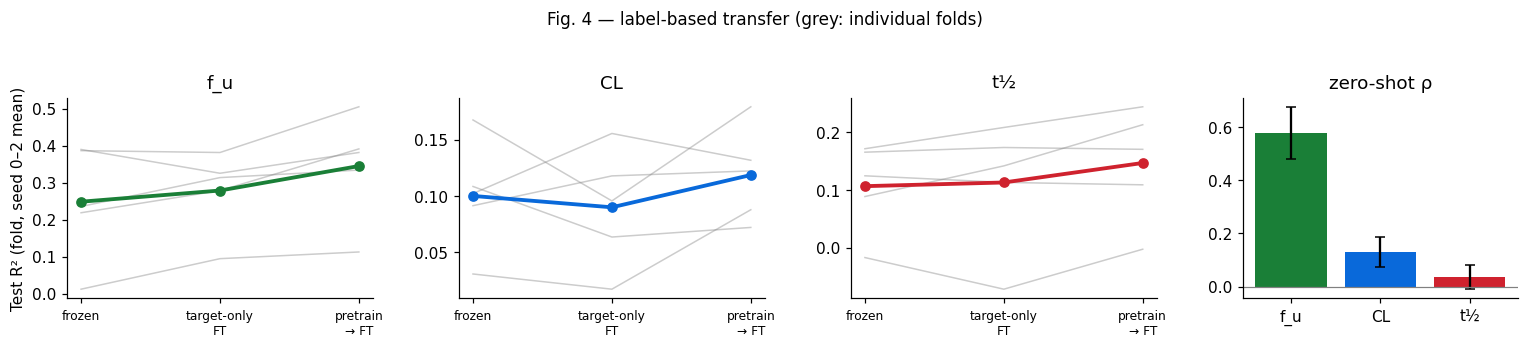

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.0), gridspec_kw={'width_ratios': [1, 1, 1, 0.9]})
for ax, p in zip(axes[:3], PROPS):
    d = fold_r2[p]
    for fold, row in d.iterrows():
        ax.plot(range(3), row.values, color='gray', alpha=0.4, lw=1)
    ax.plot(range(3), d.mean().values, color=COLOR[p], marker='o', lw=2.5)
    ax.set_xticks(range(3))
    ax.set_xticklabels(['frozen', 'target-only\nFT', 'pretrain\n→ FT'], fontsize=8)
    ax.set_title(LABEL[p])
axes[0].set_ylabel('Test R² (fold, seed 0–2 mean)')
zs = pre.groupby('property')['zero_shot_rho']
axes[3].bar([LABEL[p] for p in PROPS], [zs.mean()[p] for p in PROPS], yerr=[zs.std()[p] for p in PROPS],
            color=[COLOR[p] for p in PROPS], capsize=3)
axes[3].set_title('zero-shot ρ')
axes[3].axhline(0, color='gray', lw=0.8)
fig.suptitle('Fig. 4 — label-based transfer (grey: individual folds)', fontsize=11, y=1.04)
plt.tight_layout()
plt.show()

### 3.5b RMSE · MAE (log10 units)

Stored RMSE is in z-score units (target standardised with per-fold train statistics). Multiplying by the per-fold `log10_std` gives RMSE in original log10 units, and `10^RMSE` reads as a typical fold error (how many times off).
MAE is converted the same way. Runs that did not store MAE (earlier versions of 09 and 10) have an empty MAE cell.

In [18]:
norm = pd.read_csv(os.path.join(CV_DIR, 'target_norm_stats.csv')).rename(columns={'Fold': 'fold', 'Property': 'property'})


def with_log_rmse(df):
    df = df.merge(norm[['fold', 'property', 'log10_std']], on=['fold', 'property'])
    df = df.assign(rmse_log=df['rmse'] * df['log10_std'])
    return df.assign(mae_log=df['mae'] * df['log10_std'] if 'mae' in df else np.nan)


sig_l, ft_l, pre_l = with_log_rmse(sig_runs), with_log_rmse(ft), with_log_rmse(pre)
rows = []
for p in PROPS:
    b10 = sig_l[(sig_l['method'] == 'Baseline') & (sig_l['property'] == p)]
    rows.append({'endpoint': LABEL[p], 'model': 'frozen (10 seeds)', 'RMSE (z)': b10['rmse'].mean(),
                 'RMSE (log10)': b10['rmse_log'].mean(), 'fold-error': 10 ** b10['rmse_log'].mean(),
                 'MAE (log10)': b10['mae_log'].mean()})
    fm = sig_l[sig_l['property'] == p].groupby(['method', 'fold'])[['rmse_log', 'mae_log']].mean().unstack('method')
    for m in DA_METHODS:
        r, a = fm['rmse_log'], fm['mae_log']
        rows.append({'endpoint': LABEL[p], 'model': f'{m} (10 seeds)', 'RMSE (log10)': r[m].mean(),
                     'ΔRMSE vs frozen': (r[m] - r['Baseline']).mean(), 'p (RMSE)': ttest_rel(r[m], r['Baseline']).pvalue,
                     'MAE (log10)': a[m].mean(), 'ΔMAE vs frozen': (a[m] - a['Baseline']).mean(),
                     'p (MAE)': ttest_rel(a[m], a['Baseline']).pvalue if a[m].notna().all() else np.nan})
    fz = sig_l[(sig_l['method'] == 'Baseline') & (sig_l['property'] == p) & sig_l['seed'].isin(SEEDS_FT)].groupby('fold')[['rmse_log', 'mae_log']].mean()
    for name, d in [(f'target-only FT k={K} (seed 0–2)', ft_l[(ft_l['k'] == K) & ft_l['seed'].isin(SEEDS_FT)]),
                    ('pretrain → FT (seed 0–2)', pre_l[pre_l['seed'].isin(SEEDS_FT)])]:
        m = d[d['property'] == p].groupby('fold')[['rmse_log', 'mae_log']].mean()
        has_mae = m['mae_log'].notna().all() and fz['mae_log'].notna().all()
        rows.append({'endpoint': LABEL[p], 'model': name, 'RMSE (log10)': m['rmse_log'].mean(),
                     'fold-error': 10 ** m['rmse_log'].mean(),
                     'ΔRMSE vs frozen': (m['rmse_log'] - fz['rmse_log']).mean(),
                     'p (RMSE)': ttest_rel(m['rmse_log'], fz['rmse_log']).pvalue,
                     'MAE (log10)': m['mae_log'].mean() if has_mae else np.nan,
                     'ΔMAE vs frozen': (m['mae_log'] - fz['mae_log']).mean() if has_mae else np.nan,
                     'p (MAE)': ttest_rel(m['mae_log'], fz['mae_log']).pvalue if has_mae else np.nan})
pd.DataFrame(rows).set_index(['endpoint', 'model']).round(4)

RMSE (z)  RMSE (log10)  fold-error  MAE (log10)  ΔRMSE vs frozen  p (RMSE)  ΔMAE vs frozen  p (MAE)
endpoint model                                                                                                                               
f_u      frozen (10 seeds)                  0.8443        0.6784      4.7688       0.5474              NaN       NaN             NaN      NaN
         MMD (10 seeds)                        NaN        0.6858         NaN       0.5549           0.0074    0.0887          0.0075   0.1009
         CORAL (10 seeds)                      NaN        0.6816         NaN       0.5584           0.0032    0.7405          0.0110   0.3636
         DANN (10 seeds)                       NaN        0.6851         NaN       0.5537           0.0067    0.1331          0.0063   0.2393
         CDAN (10 seeds)                       NaN        0.6734         NaN       0.5481          -0.0050    0.4799          0.0007   0.9274
         Importance Weighting (10 seeds)       NaN        0.6808         NaN       0.5468           0.0024    0.7597         -0.0006   0.9388
         target-only FT k=4 (seed 0–2)         NaN        0.6663      4.6375       0.5288          -0.0126    0.3897         -0.0152   0.2436
         pretrain → FT (seed 0–2)              NaN        0.6326      4.2917       0.5110          -0.0462    0.0370         -0.0330   0.0165
CL       frozen (10 seeds)                  0.9482        0.6156      4.1270       0.4585              NaN       NaN             NaN      NaN
         MMD (10 seeds)                        NaN        0.6163         NaN       0.4597           0.0007    0.7513          0.0011   0.4987
         CORAL (10 seeds)                      NaN        0.6158         NaN       0.4597           0.0002    0.9126          0.0011   0.5673
         DANN (10 seeds)                       NaN        0.6178         NaN       0.4604           0.0022    0.4471          0.0018   0.5145
         CDAN (10 seeds)                       NaN        0.6124         NaN       0.4560          -0.0033    0.2823         -0.0026   0.4598
         Importance Weighting (10 seeds)       NaN        0.6151         NaN       0.4581          -0.0006    0.7624         -0.0005   0.7776
         target-only FT k=4 (seed 0–2)         NaN        0.6170      4.1404       0.4576           0.0025    0.7694          0.0016   0.8451
         pretrain → FT (seed 0–2)              NaN        0.6077      4.0523       0.4519          -0.0068    0.2607         -0.0042   0.2658
t½       frozen (10 seeds)                  0.9484        0.5892      3.8836       0.4485              NaN       NaN             NaN      NaN
         MMD (10 seeds)                        NaN        0.5888         NaN       0.4493          -0.0005    0.8684          0.0008   0.4749
         CORAL (10 seeds)                      NaN        0.5880         NaN       0.4485          -0.0012    0.6518         -0.0000   0.9878
         DANN (10 seeds)                       NaN        0.5893         NaN       0.4494           0.0000    0.9628          0.0008   0.2388
         CDAN (10 seeds)                       NaN        0.5886         NaN       0.4484          -0.0007    0.7507         -0.0002   0.9259
         Importance Weighting (10 seeds)       NaN        0.5876         NaN       0.4472          -0.0016    0.1450         -0.0013   0.1491
         target-only FT k=4 (seed 0–2)         NaN        0.5795      3.7977       0.4411          -0.0030    0.6305         -0.0027   0.6363
         pretrain → FT (seed 0–2)              NaN        0.5688      3.7048       0.4321          -0.0137    0.2000         -0.0117   0.2441

### Performance table for the paper (Baseline / distribution-based DA)

10 seeds × 5 folds. 5-fold mean per seed, then the mean over seeds. MAE and RMSE in log10 units. Also saved as CSV in `results/paper_tables/`.

In [19]:
perf = (sig_l.groupby(['property', 'method', 'seed'])[['r2', 'rho', 'mae_log', 'rmse_log']].mean()
        .groupby(['property', 'method']).mean())
perf.columns = ['R²', 'ρ', 'MAE', 'RMSE']

baseline_table = perf.xs('Baseline', level='method').loc[PROPS].rename(index=LABEL).rename_axis('endpoint')
da_table_paper = perf.loc[[(p, m) for p in PROPS for m in DA_METHODS]]
da_table_paper.index = pd.MultiIndex.from_tuples([(LABEL[p], m) for p, m in da_table_paper.index], names=['endpoint', 'method'])

PAPER_DIR = os.path.join(RES, 'paper_tables')
os.makedirs(PAPER_DIR, exist_ok=True)
baseline_table.round(3).to_csv(os.path.join(PAPER_DIR, 'baseline_performance.csv'), encoding='utf-8-sig')
da_table_paper.round(3).to_csv(os.path.join(PAPER_DIR, 'da_performance.csv'), encoding='utf-8-sig')

baseline_table.round(3)

,R²,ρ,MAE,RMSE
endpoint,,,,
f_u,0.252,0.584,0.547,0.678
CL,0.097,0.365,0.459,0.616
t½,0.084,0.399,0.449,0.589


In [20]:
da_table_paper.round(3)

R²      ρ    MAE   RMSE
endpoint method                                          
f_u      MMD                   0.236  0.575  0.555  0.686
         CORAL                 0.251  0.583  0.558  0.682
         DANN                  0.237  0.579  0.554  0.685
         CDAN                  0.266  0.597  0.548  0.673
         Importance Weighting  0.244  0.588  0.547  0.681
CL       MMD                   0.095  0.363  0.460  0.616
         CORAL                 0.096  0.365  0.460  0.616
         DANN                  0.090  0.361  0.460  0.618
         CDAN                  0.106  0.367  0.456  0.612
         Importance Weighting  0.098  0.364  0.458  0.615
t½       MMD                   0.083  0.402  0.449  0.589
         CORAL                 0.088  0.402  0.449  0.588
         DANN                  0.083  0.399  0.449  0.589
         CDAN                  0.086  0.399  0.448  0.589
         Importance Weighting  0.089  0.398  0.447  0.588

### DA performance table visualisations — comparison by method

The same table drawn four ways. Pick the one that fits the purpose for the paper.

| Method | What it shows | Recommended use |
|---|---|---|
| **A. Bar small multiples** | absolute values + baseline reference line | when showing the performance level itself |
| **B. Difference dot plot + 95% CI** | difference from the baseline and its uncertainty | **main-text figure (most honest: "the difference is within the CI")** |
| **C. Relative-change heatmap** | 15 combinations × 4 metrics on one page | supplementary, summary at a glance |
| **D. Dumbbell (baseline → method)** | direction and size of the shift per method | presentation slides |

Colour: the five methods use a fixed-order categorical palette (blue, orange, aqua, yellow, magenta), the baseline is grey. Differences and changes share one direction: **"right/positive = better"** (MAE and RMSE as baseline − method).

In [21]:
METHOD_COLOR = {'MMD': '#2a78d6', 'CORAL': '#eb6834', 'DANN': '#1baf7a', 'CDAN': '#eda100', 'Importance Weighting': '#e87ba4'}
METHOD_SHORT = {'MMD': 'MMD', 'CORAL': 'CORAL', 'DANN': 'DANN', 'CDAN': 'CDAN', 'Importance Weighting': 'IW'}
BASE_GRAY = '#52514e'
METRICS = [('R²', 'r2', True), ('ρ', 'rho', True), ('MAE', 'mae_log', False), ('RMSE', 'rmse_log', False)]  # (name, column, higher is better)
plt.rcParams.update({'axes.grid': True, 'grid.color': '#e6e5e0', 'grid.linewidth': 0.6, 'axes.axisbelow': True,
                     'axes.edgecolor': '#8a8984', 'xtick.color': '#52514e', 'ytick.color': '#52514e'})

# Per-fold (seed-mean) values → for computing differences and 95% CIs
fold_vals = sig_l.groupby(['property', 'method', 'fold'])[['r2', 'rho', 'mae_log', 'rmse_log']].mean()

#### A. Bar small multiples (absolute values)
One panel (one axis) per metric, five method bars per endpoint, grey line = baseline. Metrics have different scales, so they are not mixed on one axis.

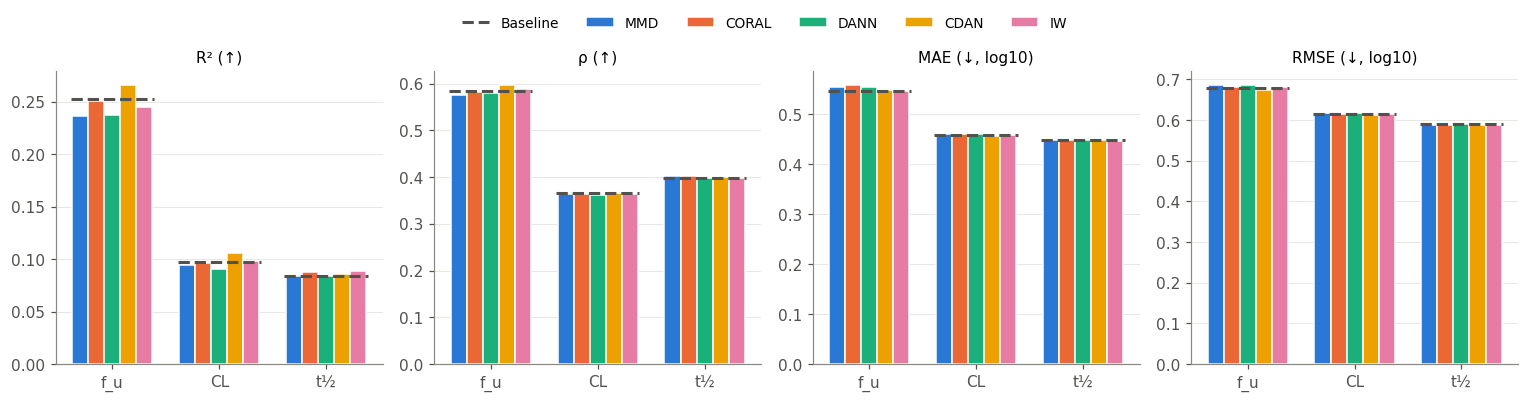

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.4))
w = 0.15
for ax, (mname, col, _) in zip(axes, METRICS):
    for j, p in enumerate(PROPS):
        base_v = baseline_table.loc[LABEL[p], mname]
        for i, m in enumerate(DA_METHODS):
            v = da_table_paper.loc[(LABEL[p], m), mname]
            ax.bar(j + (i - 2) * w, v, width=w, color=METHOD_COLOR[m], edgecolor='white', linewidth=1,
                   label=METHOD_SHORT[m] if j == 0 else None)
        ax.hlines(base_v, j - 2.6 * w, j + 2.6 * w, color=BASE_GRAY, lw=2, ls='--', label='Baseline' if j == 0 else None)
    ax.set_xticks(range(len(PROPS)))
    ax.set_xticklabels([LABEL[p] for p in PROPS])
    ax.set_title(mname + (' (↑)' if METRICS[[x[0] for x in METRICS].index(mname)][2] else ' (↓, log10)'), fontsize=10)
    ax.grid(axis='x', visible=False)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=6, bbox_to_anchor=(0.5, 1.08), frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

#### B. Difference dot plot vs baseline + 95% CI (recommended)
Point = mean per-fold (10-seed mean) difference, horizontal line = 95% t-CI over 5 folds. Crossing the 0 line means improvement; if the CI contains 0, no difference can be claimed.

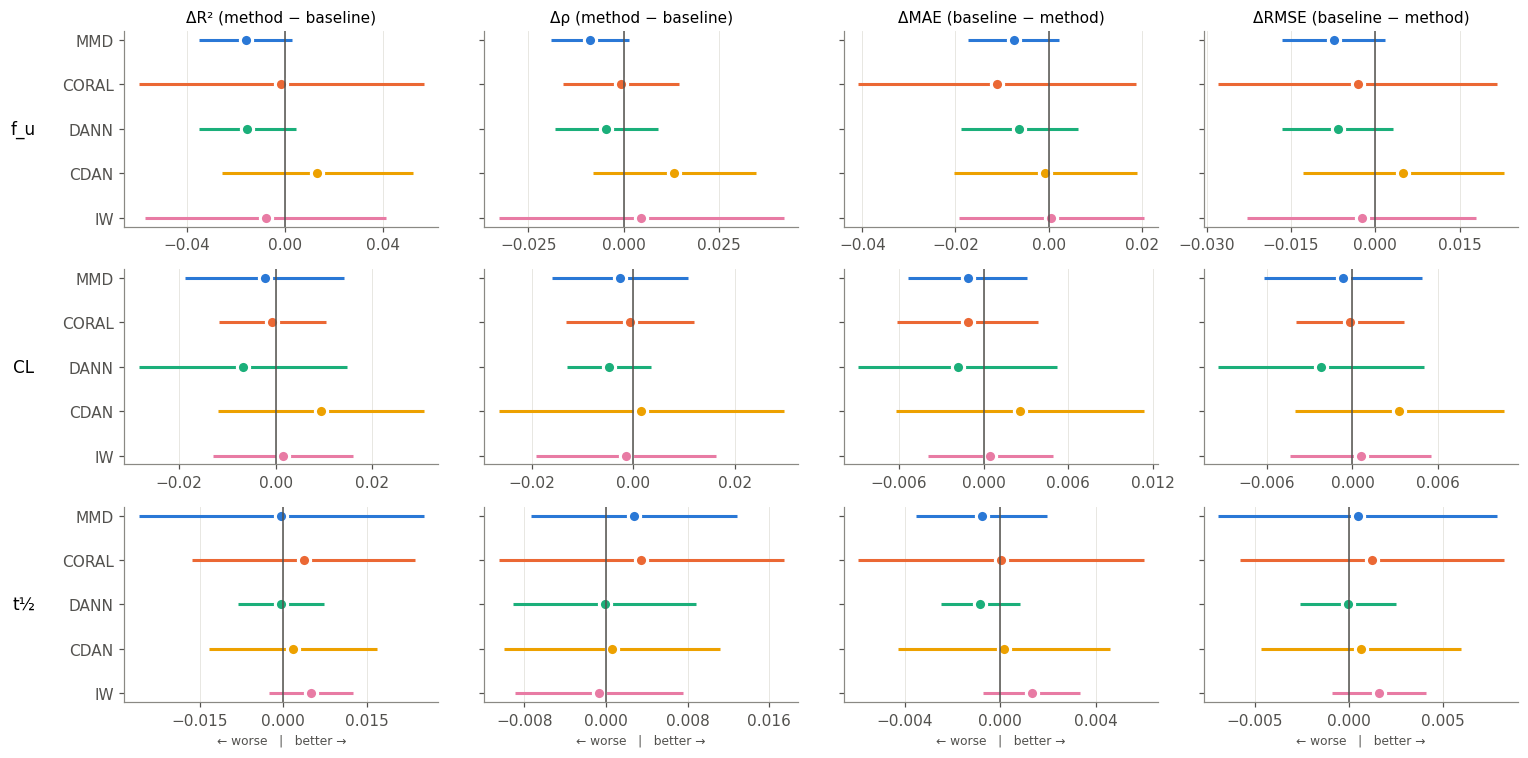

In [23]:
from scipy.stats import t as t_dist
from matplotlib.ticker import MaxNLocator


def diff_ci(p, m, col, higher_better):
    a = fold_vals.loc[(p, m)][col]
    b = fold_vals.loc[(p, 'Baseline')][col]
    d = (a - b) if higher_better else (b - a)
    half = t_dist.ppf(0.975, len(d) - 1) * d.std(ddof=1) / np.sqrt(len(d))
    return d.mean(), half


fig, axes = plt.subplots(len(PROPS), 4, figsize=(14, 7), sharey=True)
for r, p in enumerate(PROPS):
    for c, (mname, col, hb) in enumerate(METRICS):
        ax = axes[r, c]
        for i, m in enumerate(DA_METHODS):
            mean, half = diff_ci(p, m, col, hb)
            y = len(DA_METHODS) - 1 - i
            ax.hlines(y, mean - half, mean + half, color=METHOD_COLOR[m], lw=2)
            ax.plot(mean, y, 'o', ms=8, color=METHOD_COLOR[m], mec='white', mew=2)
        ax.axvline(0, color=BASE_GRAY, lw=1)
        ax.xaxis.set_major_locator(MaxNLocator(4))
        ax.set_yticks(range(len(DA_METHODS)))
        ax.set_yticklabels([METHOD_SHORT[m] for m in DA_METHODS][::-1])
        ax.grid(axis='y', visible=False)
        if r == 0:
            ax.set_title(f'Δ{mname}' + (' (method − baseline)' if hb else ' (baseline − method)'), fontsize=10)
        if c == 0:
            ax.set_ylabel(LABEL[p], fontsize=11, rotation=0, labelpad=25, va='center')
        if r == len(PROPS) - 1:
            ax.set_xlabel('← worse   |   better →', fontsize=8, color='#52514e')
plt.tight_layout()
plt.show()

#### C. Relative-change heatmap
Cell value = relative change (%) vs the baseline, positive = better (sign flipped for MAE and RMSE). Diverging colours (blue = better, red = worse, grey = 0), colour range symmetric around 0.
Caution: R² has a small baseline (t½ 0.084), so the same absolute difference looks like a large relative %.

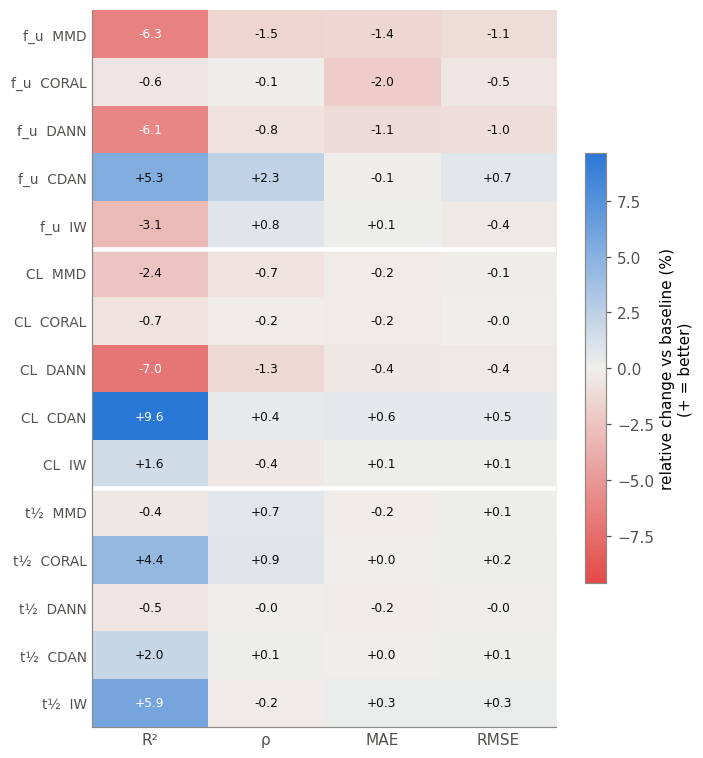

In [24]:
from matplotlib.colors import LinearSegmentedColormap

div_cmap = LinearSegmentedColormap.from_list('div', ['#e34948', '#f0efec', '#2a78d6'])
rel = pd.DataFrame(index=da_table_paper.index, columns=[m for m, _, _ in METRICS], dtype=float)
for (ep, m) in da_table_paper.index:
    for mname, _, hb in METRICS:
        v, b = da_table_paper.loc[(ep, m), mname], baseline_table.loc[ep, mname]
        rel.loc[(ep, m), mname] = 100 * ((v - b) if hb else (b - v)) / abs(b)

lim = np.nanmax(np.abs(rel.values))
fig, ax = plt.subplots(figsize=(6.5, 7))
im = ax.imshow(rel.values, cmap=div_cmap, vmin=-lim, vmax=lim, aspect='auto')
for i in range(rel.shape[0]):
    for j in range(rel.shape[1]):
        v = rel.iat[i, j]
        ax.text(j, i, f'{v:+.1f}', ha='center', va='center', fontsize=8,
                color='white' if abs(v) > 0.6 * lim else '#0b0b0b')
ax.set_xticks(range(rel.shape[1]))
ax.set_xticklabels(rel.columns)
ax.set_yticks(range(rel.shape[0]))
ax.set_yticklabels([f'{ep}  {METHOD_SHORT[m]}' for ep, m in rel.index], fontsize=9)
for k in range(1, len(PROPS)):
    ax.axhline(k * len(DA_METHODS) - 0.5, color='white', lw=3)
ax.grid(False)
ax.tick_params(length=0)
cb = fig.colorbar(im, ax=ax, shrink=0.6)
cb.set_label('relative change vs baseline (%)\n(+ = better)')
plt.tight_layout()
plt.show()

#### D. dumbbell (baseline → method)
Grey point = baseline, coloured point = method. Line length is the change, direction is better/worse. Panels per metric, rows per endpoint.
Columns of the same metric share the x-axis width (centred on each row's baseline), so line lengths can be compared directly across endpoints.

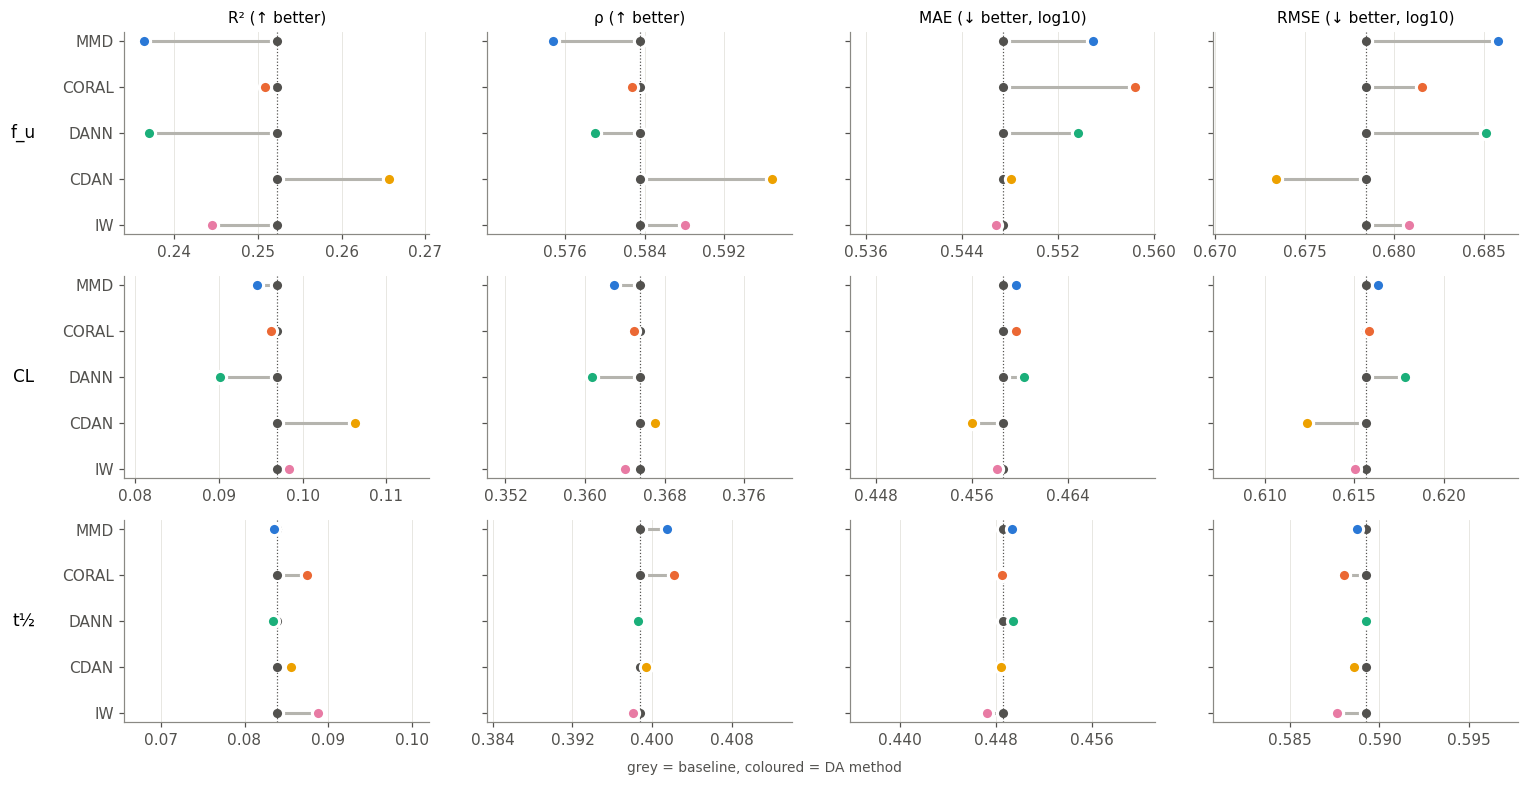

In [25]:
# Use the same x-axis width within a metric column (centred on each row's baseline) → small differences are not exaggerated by per-panel autoscaling
span = {mname: 1.15 * max(abs(da_table_paper.loc[(LABEL[p], m), mname] - baseline_table.loc[LABEL[p], mname])
                          for p in PROPS for m in DA_METHODS) for mname, _, _ in METRICS}
fig, axes = plt.subplots(len(PROPS), 4, figsize=(14, 7), sharey=True)
for r, p in enumerate(PROPS):
    ep = LABEL[p]
    for c, (mname, _, hb) in enumerate(METRICS):
        ax = axes[r, c]
        b = baseline_table.loc[ep, mname]
        for i, m in enumerate(DA_METHODS):
            y = len(DA_METHODS) - 1 - i
            v = da_table_paper.loc[(ep, m), mname]
            ax.plot([b, v], [y, y], color='#b5b4ae', lw=2, zorder=1)
            ax.plot(b, y, 'o', ms=8, color=BASE_GRAY, mec='white', mew=2, zorder=2)
            ax.plot(v, y, 'o', ms=8, color=METHOD_COLOR[m], mec='white', mew=2, zorder=3)
        ax.axvline(b, color=BASE_GRAY, lw=0.8, ls=':')
        ax.set_xlim(b - span[mname], b + span[mname])
        ax.xaxis.set_major_locator(MaxNLocator(4))
        ax.set_yticks(range(len(DA_METHODS)))
        ax.set_yticklabels([METHOD_SHORT[m] for m in DA_METHODS][::-1])
        ax.grid(axis='y', visible=False)
        if r == 0:
            ax.set_title(mname + (' (↑ better)' if hb else ' (↓ better, log10)'), fontsize=10)
        if c == 0:
            ax.set_ylabel(ep, fontsize=11, rotation=0, labelpad=25, va='center')
fig.text(0.5, -0.01, 'grey = baseline, coloured = DA method', ha='center', fontsize=9, color='#52514e')
plt.tight_layout()
plt.show()

## 3.6 Synthesis: endpoint × transfer route

Hypothesis: in vitro↔in vivo mechanistic distance **f_u < CL < t½** → domain adaptability **f_u > CL > t½**.

In [26]:
synth = pd.DataFrame({LABEL[p]: {
    'P(x) gap: MMD (median σ)': p3[p]['mmd_median_heuristic'],
    'P(x) gap: domain AUC (LR)': p5[p]['lr_auc_mean'],
    'label correspondence: 1-NN ρ (T≥0.4)': p4[p]['spearman_rho'],
    'label correspondence: rel. to within': p4[p]['relative_to_within'],
    'zero-shot ρ (pretrained)': transfer.loc[LABEL[p], 'zero-shot ρ'],
    'best DA ΔR² (10 seeds)': da_table.loc[LABEL[p], 'delta_r2'].max(),
    'mean DA ΔR² (10 seeds)': da_table.loc[LABEL[p], 'delta_r2'].mean(),
    'label transfer ΔR² vs frozen (3 seeds)': transfer.loc[LABEL[p], 'ΔR² vs frozen'],
} for p in PROPS})


def order_ok(row):
    v = row.values
    if np.allclose(v, v[0], rtol=0.15):
        return '≈ same'
    return '✅ f_u > CL > t½' if v[0] > v[1] > v[2] else ('~ f_u highest' if v[0] == v.max() else '✗')


synth['order vs hypothesis'] = synth.apply(order_ok, axis=1)
synth.round(3)

,f_u,CL,t½,order vs hypothesis
P(x) gap: MMD (median σ),0.319,0.331,0.301,≈ same
P(x) gap: domain AUC (LR),0.930,0.957,0.957,≈ same
label correspondence: 1-NN ρ (T≥0.4),0.699,0.193,0.047,✅ f_u > CL > t½
label correspondence: rel. to within,1.097,0.412,0.086,✅ f_u > CL > t½
zero-shot ρ (pretrained),0.578,0.129,0.036,✅ f_u > CL > t½
best DA ΔR² (10 seeds),0.013,0.009,0.005,✅ f_u > CL > t½
mean DA ΔR² (10 seeds),-0.005,0.000,0.002,✗
label transfer ΔR² vs frozen (3 seeds),0.096,0.019,0.040,~ f_u highest


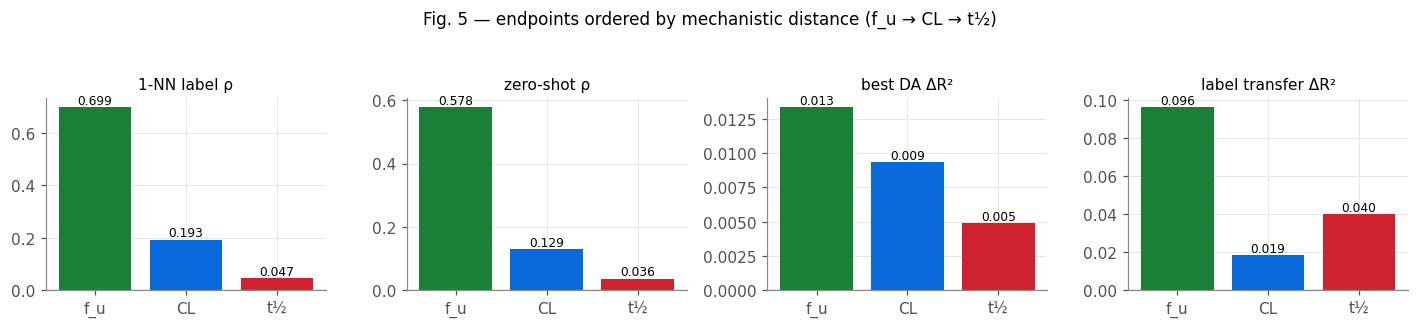

In [27]:
panels = [('label correspondence: 1-NN ρ (T≥0.4)', '1-NN label ρ'),
          ('zero-shot ρ (pretrained)', 'zero-shot ρ'),
          ('best DA ΔR² (10 seeds)', 'best DA ΔR²'),
          ('label transfer ΔR² vs frozen (3 seeds)', 'label transfer ΔR²')]
fig, axes = plt.subplots(1, 4, figsize=(13, 2.8))
for ax, (key, title) in zip(axes, panels):
    vals = [synth.loc[key, LABEL[p]] for p in PROPS]
    ax.bar([LABEL[p] for p in PROPS], vals, color=[COLOR[p] for p in PROPS])
    ax.axhline(0, color='gray', lw=0.8)
    ax.set_title(title, fontsize=10)
    for i, v in enumerate(vals):
        ax.text(i, v, f'{v:.3f}', ha='center', va='bottom' if v >= 0 else 'top', fontsize=8)
fig.suptitle('Fig. 5 — endpoints ordered by mechanistic distance (f_u → CL → t½)', fontsize=11, y=1.05)
plt.tight_layout()
plt.show()

### 3.6b Synthesis visualisations — several formats

Compares every transfer route (target-only FT, five distribution-based DA methods, label-based transfer) with the frozen baseline at once.
09 and 10 only have seeds 0–2, so **every model is matched to seeds 0–2** for the per-fold paired comparison (which is why the DA numbers differ slightly from the 10-seed table).

| Format | What it shows | Recommended use |
|---|---|---|
| **S1. All-model forest plot** | ΔR², Δρ, ΔRMSE + 95% CI, grouped by route | **main-text synthesis figure** |
| **S2. Mechanism scatter** | P(x) gap vs gain / label correspondence vs gain | **key-claim figure (Discussion)** |
| **S3. Δ heatmap** | model × endpoint × metric on one page | supplementary |
| **S4. Rank change (bump chart)** | R² rank per endpoint | presentation |
| **S5. Route summary bars** | representative ΔR² per route (DA max and mean, target-only FT, label transfer) | presentation, summary |

Colour: the five DA methods keep the colours above, target-only FT is grey, label transfer (pretrain → FT) is green. Positive = better (RMSE as baseline − model).

> **Caution — frozen reference for seeds 0–2:** for t½ the frozen R² over seeds 0–2 is 0.107, higher than the 10-seed mean (0.084). So in this section every DA method on t½ looks worse by −0.02 to −0.03, but in the 10-seed comparison (3.4, figure B above) they are near 0. Judge the DA effect itself from the 10-seed results in 3.4, and read this section as a **relative comparison between routes**.

In [28]:
ALL_MODELS = ['target-only FT'] + DA_METHODS + ['pretrain → FT']
MODEL_COLOR = {**METHOD_COLOR, 'target-only FT': '#8a8984', 'pretrain → FT': '#008300', 'frozen': BASE_GRAY}
MODEL_SHORT = {**METHOD_SHORT, 'target-only FT': 'target-only FT', 'pretrain → FT': 'pretrain → FT', 'frozen': 'frozen'}
ROUTE = {'target-only FT': 'target-only', 'pretrain → FT': 'label-based', **{m: 'distribution-based' for m in DA_METHODS}}

s3 = sig_l[sig_l['seed'].isin(SEEDS_FT)]
frames = [s3.assign(model=s3['method'].replace({'Baseline': 'frozen'})),
          ft_l[(ft_l['k'] == K) & ft_l['seed'].isin(SEEDS_FT)].assign(model='target-only FT'),
          pre_l[pre_l['seed'].isin(SEEDS_FT)].assign(model='pretrain → FT')]
cols = ['model', 'property', 'seed', 'fold', 'r2', 'rho', 'rmse_log']
allf = pd.concat([f[cols] for f in frames]).groupby(['property', 'model', 'fold'])[['r2', 'rho', 'rmse_log']].mean()
CMP_METRICS = [('R²', 'r2', True), ('ρ', 'rho', True), ('RMSE', 'rmse_log', False)]


def delta(p, m, col, hb):
    a, b = allf.loc[(p, m)][col], allf.loc[(p, 'frozen')][col]
    d = (a - b) if hb else (b - a)
    half = t_dist.ppf(0.975, len(d) - 1) * d.std(ddof=1) / np.sqrt(len(d))
    return d.mean(), half, ttest_rel(a, b).pvalue


cmp = pd.DataFrame([{'endpoint': LABEL[p], 'model': m, 'metric': mn, 'delta': delta(p, m, c, hb)[0],
                     'ci': delta(p, m, c, hb)[1], 'p': delta(p, m, c, hb)[2]}
                    for p in PROPS for m in ALL_MODELS for mn, c, hb in CMP_METRICS])
cmp.pivot_table(index=['endpoint', 'model'], columns='metric', values='delta').loc[[LABEL[p] for p in PROPS]].round(4)

metric                           RMSE      R²       ρ
endpoint model                                       
f_u      CDAN                  0.0082  0.0216  0.0147
         CORAL                 0.0042  0.0157 -0.0002
         DANN                 -0.0077 -0.0156  0.0017
         Importance Weighting  0.0012 -0.0003  0.0111
         MMD                  -0.0055 -0.0134 -0.0008
         pretrain → FT         0.0462  0.0965  0.0683
         target-only FT        0.0126  0.0303  0.0366
CL       CDAN                  0.0025  0.0063 -0.0079
         CORAL                -0.0030 -0.0095 -0.0065
         DANN                 -0.0043 -0.0131 -0.0212
         Importance Weighting -0.0040 -0.0118 -0.0123
         MMD                   0.0012  0.0030  0.0020
         pretrain → FT         0.0068  0.0186  0.0211
         target-only FT       -0.0025 -0.0101 -0.0041
t½       CDAN                 -0.0091 -0.0310 -0.0097
         CORAL                -0.0063 -0.0232 -0.0006
         DANN                 -0.0098 -0.0334 -0.0089
         Importance Weighting -0.0098 -0.0335 -0.0168
         MMD                  -0.0070 -0.0261 -0.0048
         pretrain → FT         0.0137  0.0402  0.0358
         target-only FT        0.0030  0.0064  0.0233

#### S1. All-model forest plot (Δ vs frozen, 95% CI)
From the top: target-only → five distribution-based DA methods → label-based. Dashed lines separate the routes.

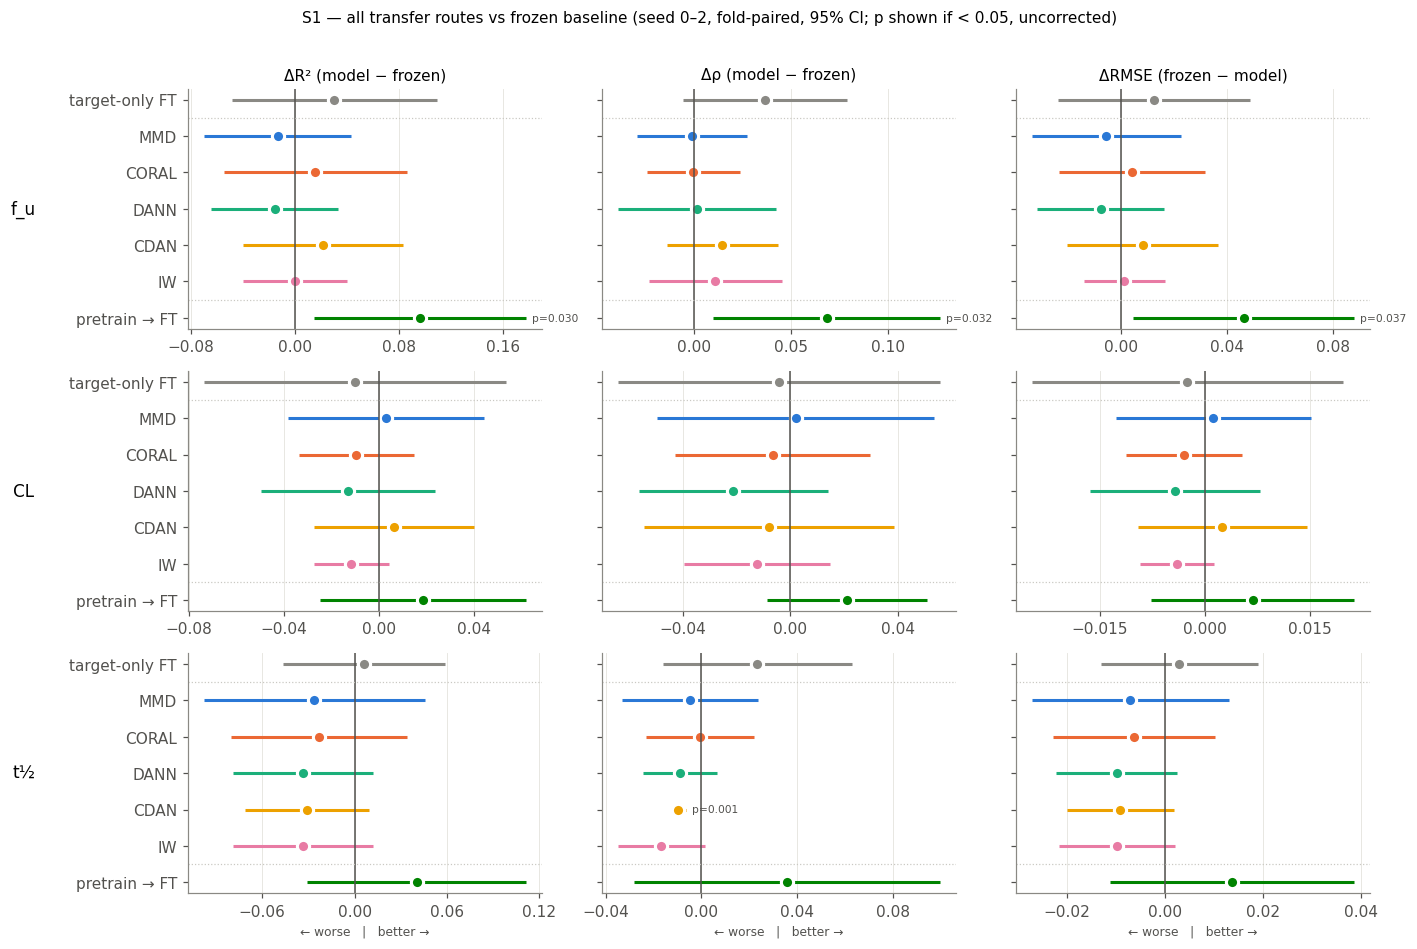

In [29]:
fig, axes = plt.subplots(len(PROPS), len(CMP_METRICS), figsize=(13, 8.5), sharey=True)
for r, p in enumerate(PROPS):
    for c, (mn, col, hb) in enumerate(CMP_METRICS):
        ax = axes[r, c]
        for i, m in enumerate(ALL_MODELS):
            d, half, pv = delta(p, m, col, hb)
            y = len(ALL_MODELS) - 1 - i
            ax.hlines(y, d - half, d + half, color=MODEL_COLOR[m], lw=2)
            ax.plot(d, y, 'o', ms=8, color=MODEL_COLOR[m], mec='white', mew=2)
            if pv < 0.05:
                ax.annotate(f'p={pv:.3f}', (d + half, y), xytext=(4, 0), textcoords='offset points',
                            va='center', fontsize=7, color='#52514e')
        ax.axvline(0, color=BASE_GRAY, lw=1)
        for yb in (len(ALL_MODELS) - 1.5, 0.5):
            ax.axhline(yb, color='#c9c8c2', lw=0.8, ls=':')
        ax.xaxis.set_major_locator(MaxNLocator(4))
        ax.set_yticks(range(len(ALL_MODELS)))
        ax.set_yticklabels([MODEL_SHORT[m] for m in ALL_MODELS][::-1])
        ax.grid(axis='y', visible=False)
        if r == 0:
            ax.set_title(f'Δ{mn}' + (' (model − frozen)' if hb else ' (frozen − model)'), fontsize=10)
        if c == 0:
            ax.set_ylabel(LABEL[p], fontsize=11, rotation=0, labelpad=30, va='center')
        if r == len(PROPS) - 1:
            ax.set_xlabel('← worse   |   better →', fontsize=8, color='#52514e')
fig.suptitle('S1 — all transfer routes vs frozen baseline (seed 0–2, fold-paired, 95% CI; p shown if < 0.05, uncorrected)',
             fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

#### S2. Mechanism scatter — what explains the gain?
Left: x = P(x) gap (embedding MMD); right: x = label correspondence (1-NN ρ). y = ΔR² vs frozen.
Green = label-based transfer (error bars = 95% CI), blue = mean of the five distribution-based DA methods.
With only three endpoints, no regression line or correlation coefficient is drawn — read the direction only.
The left x-axis starts at 0 so that the nearly identical P(x) gaps of the three endpoints show as such. On the right, f_u gains the most, but t½ (ρ ≈ 0.05) gains more than CL (ρ ≈ 0.19), so the relation is not monotonic.

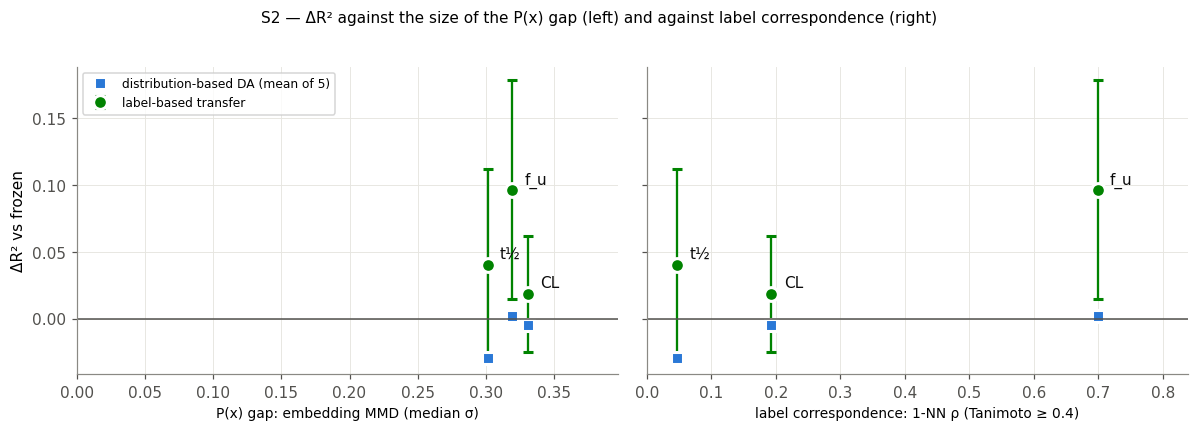

In [30]:
xs = {'P(x) gap: embedding MMD (median σ)': {p: p3[p]['mmd_median_heuristic'] for p in PROPS},
      'label correspondence: 1-NN ρ (Tanimoto ≥ 0.4)': {p: p4[p]['spearman_rho'] for p in PROPS}}
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, (xlabel, xv) in zip(axes, xs.items()):
    for p in PROPS:
        d, half, _ = delta(p, 'pretrain → FT', 'r2', True)
        da_mean = np.mean([delta(p, m, 'r2', True)[0] for m in DA_METHODS])
        ax.errorbar(xv[p], d, yerr=half, fmt='o', ms=9, color='#008300', mec='white', mew=2, capsize=3, lw=1.5,
                    label='label-based transfer' if p == PROPS[0] else None)
        ax.plot(xv[p], da_mean, 's', ms=8, color='#2a78d6', mec='white', mew=2,
                label='distribution-based DA (mean of 5)' if p == PROPS[0] else None)
        ax.annotate(LABEL[p], (xv[p], d), xytext=(8, 4), textcoords='offset points', fontsize=10, color='#0b0b0b')
    ax.axhline(0, color=BASE_GRAY, lw=1)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_xlim(0, max(xv.values()) * 1.2)   # start at 0 → nearly identical gaps are not magnified into looking different
axes[0].set_ylabel('ΔR² vs frozen')
axes[0].legend(fontsize=8, loc='upper left')
fig.suptitle('S2 — ΔR² against the size of the P(x) gap (left) and against label correspondence (right)', fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

#### S3. Δ heatmap (model × endpoint, per metric)
Cell = Δ vs frozen (positive = better). Metrics have different scales, so each panel has its own colour range symmetric around 0.

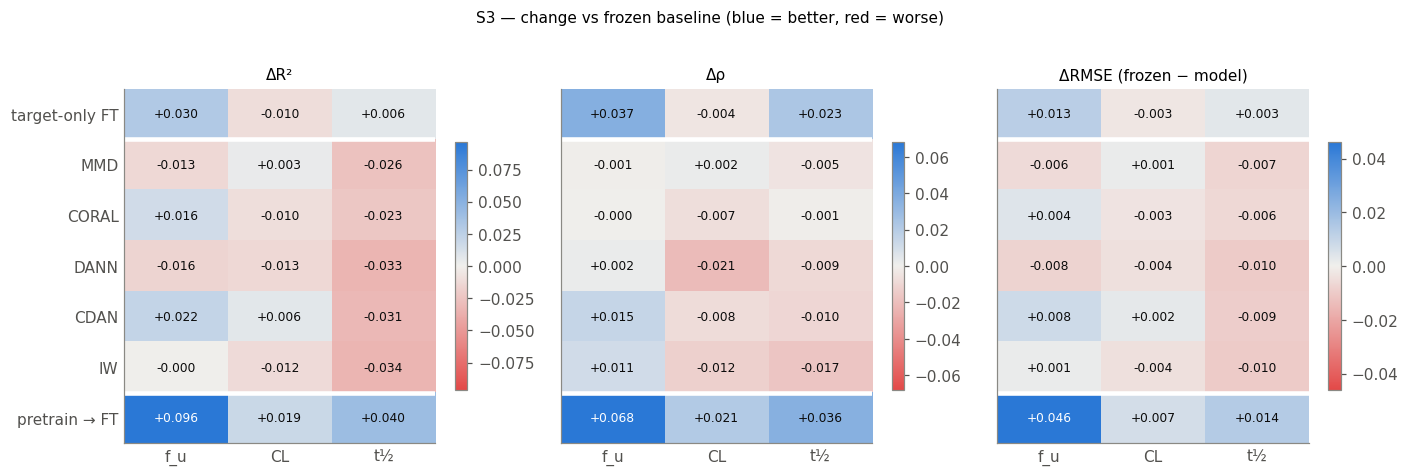

In [31]:
fig, axes = plt.subplots(1, len(CMP_METRICS), figsize=(13, 4.2))
for ax, (mn, col, hb) in zip(axes, CMP_METRICS):
    mat = np.array([[delta(p, m, col, hb)[0] for p in PROPS] for m in ALL_MODELS])
    lim = np.abs(mat).max()
    im = ax.imshow(mat, cmap=div_cmap, vmin=-lim, vmax=lim, aspect='auto')
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, f'{mat[i, j]:+.3f}', ha='center', va='center', fontsize=8,
                    color='white' if abs(mat[i, j]) > 0.6 * lim else '#0b0b0b')
    ax.set_xticks(range(len(PROPS)))
    ax.set_xticklabels([LABEL[p] for p in PROPS])
    ax.set_yticks(range(len(ALL_MODELS)))
    ax.set_yticklabels([MODEL_SHORT[m] for m in ALL_MODELS] if ax is axes[0] else [])
    for yb in (0.5, len(ALL_MODELS) - 1.5):
        ax.axhline(yb, color='white', lw=3)
    ax.set_title(f'Δ{mn}' + ('' if hb else ' (frozen − model)'), fontsize=10)
    ax.grid(False)
    ax.tick_params(length=0)
    fig.colorbar(im, ax=ax, shrink=0.7)
fig.suptitle('S3 — change vs frozen baseline (blue = better, red = worse)', fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

#### S4. Rank change (bump chart)
Test R² rank (1 = best) of the 8 models including frozen, per endpoint. Lines follow each model.

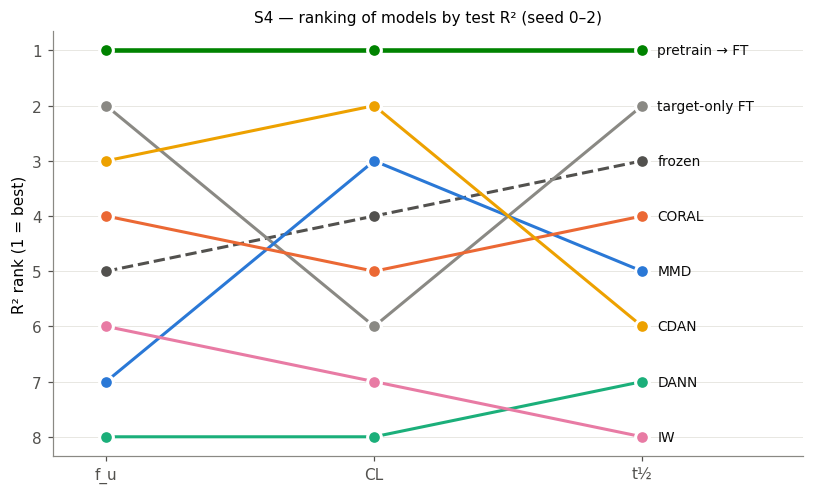

,f_u,CL,t½
frozen,5,4,3
target-only FT,2,6,2
MMD,7,3,5
CORAL,4,5,4
DANN,8,8,7
CDAN,3,2,6
Importance Weighting,6,7,8
pretrain → FT,1,1,1


In [32]:
order_models = ['frozen'] + ALL_MODELS
ranks = pd.DataFrame({LABEL[p]: pd.Series({m: allf.loc[(p, m)]['r2'].mean() for m in order_models}).rank(ascending=False)
                      for p in PROPS})
fig, ax = plt.subplots(figsize=(7.5, 4.6))
xpos = range(len(PROPS))
for m in order_models:
    ls = '--' if m == 'frozen' else '-'
    lw = 3 if m == 'pretrain → FT' else 2
    ax.plot(xpos, ranks.loc[m], ls=ls, lw=lw, marker='o', ms=9, color=MODEL_COLOR[m], mec='white', mew=2)
    ax.annotate(MODEL_SHORT[m], (len(PROPS) - 1, ranks.loc[m].iloc[-1]), xytext=(10, 0),
                textcoords='offset points', va='center', fontsize=9, color='#0b0b0b')
ax.set_xticks(list(xpos))
ax.set_xticklabels([LABEL[p] for p in PROPS])
ax.set_yticks(range(1, len(order_models) + 1))
ax.invert_yaxis()
ax.set_ylabel('R² rank (1 = best)')
ax.set_xlim(-0.2, len(PROPS) - 1 + 0.6)
ax.grid(axis='x', visible=False)
ax.set_title('S4 — ranking of models by test R² (seed 0–2)', fontsize=10)
plt.tight_layout()
plt.show()
ranks.astype(int)

#### S5. Route summary bars
Representative ΔR² per route for each endpoint: distribution-based DA max and mean, target-only FT, label-based transfer.

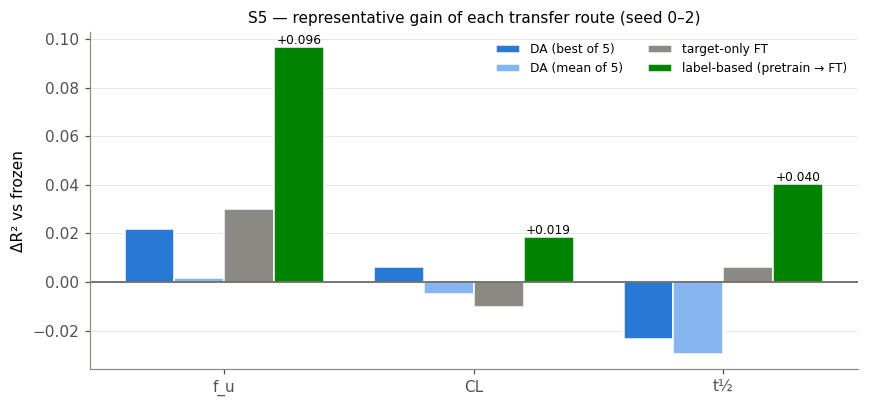

,DA (best of 5),DA (mean of 5),target-only FT,label-based (pretrain → FT)
f_u,0.0216,0.0016,0.0303,0.0965
CL,0.0063,-0.0050,-0.0101,0.0186
t½,-0.0232,-0.0295,0.0064,0.0402


In [33]:
summary_routes = pd.DataFrame({LABEL[p]: {
    'DA (best of 5)': max(delta(p, m, 'r2', True)[0] for m in DA_METHODS),
    'DA (mean of 5)': np.mean([delta(p, m, 'r2', True)[0] for m in DA_METHODS]),
    'target-only FT': delta(p, 'target-only FT', 'r2', True)[0],
    'label-based (pretrain → FT)': delta(p, 'pretrain → FT', 'r2', True)[0],
} for p in PROPS}).T
route_color = {'DA (best of 5)': '#2a78d6', 'DA (mean of 5)': '#86b6ef', 'target-only FT': '#8a8984',
               'label-based (pretrain → FT)': '#008300'}
fig, ax = plt.subplots(figsize=(8, 3.8))
w = 0.2
for i, rname in enumerate(summary_routes.columns):
    vals = summary_routes[rname].values
    ax.bar(np.arange(len(PROPS)) + (i - 1.5) * w, vals, width=w, color=route_color[rname],
           edgecolor='white', linewidth=1, label=rname)
    for j, v in enumerate(vals):
        if rname == 'label-based (pretrain → FT)':
            ax.text(j + (i - 1.5) * w, v, f'{v:+.3f}', ha='center', va='bottom' if v >= 0 else 'top', fontsize=8)
ax.axhline(0, color=BASE_GRAY, lw=1)
ax.set_xticks(range(len(PROPS)))
ax.set_xticklabels(summary_routes.index)
ax.set_ylabel('ΔR² vs frozen')
ax.grid(axis='x', visible=False)
ax.legend(fontsize=8, ncol=2, loc='upper right', frameon=False)
ax.set_title('S5 — representative gain of each transfer route (seed 0–2)', fontsize=10)
plt.tight_layout()
plt.show()
summary_routes.round(4)

## 3.6c Compound-level analysis (PKSmart format)

Uses the results of re-running `08` with per-compound test predictions saved (`results/significance_pred/predictions.csv`).
- Predictions and observations are converted back to **log10 units** with per-fold normalisation statistics, then **the 10-seed predictions are averaged per compound** (each compound belongs to exactly one test fold).
- fold error = 10^|log10 predicted − log10 observed|
- Table metrics: % within 2-, 3- and 5-fold, **GMFE** = 10^mean|error|, **AFE** (bias) = 10^mean(error) (above 1 means over-prediction), RMSE (log10), R²
- R² and RMSE here are computed **once over the seed-mean predictions pooled from all folds**, so they differ slightly from the per-fold averages in 3.3–3.5.
- `results/finetune/predictions.csv` (09, k=4) and `results/pretrain_ft/predictions.csv` (10) are included automatically if present. These are means over seeds 0–2. To see them in P1 and P2, set `PLOT_METHOD = 'pretrain → FT'`.

In [34]:
PRED_PATH = os.path.join(RES, 'significance_pred', 'predictions.csv')
HAVE_PRED = os.path.exists(PRED_PATH)
print('Prediction file:', PRED_PATH if HAVE_PRED else 'none — run the prediction-saving version of 08 first')

if HAVE_PRED:
    pr = pd.read_csv(PRED_PATH)
    # Use the 09 and 10 predictions too if present (seeds 0–2 only, so per-compound means are over 3 seeds)
    for path, name, filt in [(os.path.join(RES, 'finetune', 'predictions.csv'), 'target-only FT', lambda d: d[d['k'] == K]),
                             (os.path.join(RES, 'pretrain_ft', 'predictions.csv'), 'pretrain → FT', lambda d: d)]:
        if os.path.exists(path):
            extra = filt(pd.read_csv(path))[['property', 'seed', 'fold', 'smiles', 'y_true', 'y_pred']]
            pr = pd.concat([pr, extra.assign(method=name)], ignore_index=True)
            print(f'+ {name}: {path}')
    pr = pr.merge(norm, on=['fold', 'property'])
    pr['true_log'] = pr['y_true'] * pr['log10_std'] + pr['log10_mean']
    pr['pred_log'] = pr['y_pred'] * pr['log10_std'] + pr['log10_mean']
    # Seed-mean prediction per compound
    comp = (pr.groupby(['method', 'property', 'fold', 'smiles'], as_index=False)
              .agg(true_log=('true_log', 'first'), pred_log=('pred_log', 'mean')))
    comp['err'] = comp['pred_log'] - comp['true_log']
    comp['fold_error'] = 10 ** comp['err'].abs()
    print('methods:', sorted(comp['method'].unique()), '| compounds per endpoint:',
          comp[comp['method'] == 'Baseline'].groupby('property').size().to_dict())

Prediction file: ..\results\significance_pred\predictions.csv
+ target-only FT: ..\results\finetune\predictions.csv
+ pretrain → FT: ..\results\pretrain_ft\predictions.csv
methods: ['Baseline', 'CDAN', 'CORAL', 'DANN', 'Importance Weighting', 'MMD', 'pretrain → FT', 'target-only FT'] | compounds per endpoint: {'clearance': 1027, 'fu': 353, 'half_life': 1164}


In [35]:
def pksmart_row(d):
    fe, err, y, yp = d['fold_error'], d['err'], d['true_log'], d['pred_log']
    return pd.Series({
        'twofold error (%)': 100 * (fe <= 2).mean(),
        'threefold error (%)': 100 * (fe <= 3).mean(),
        'fivefold error (%)': 100 * (fe <= 5).mean(),
        'GMFE': 10 ** err.abs().mean(),
        'AFE (bias)': 10 ** err.mean(),
        'RMSE (log10)': np.sqrt((err ** 2).mean()),
        'R²': 1 - ((y - yp) ** 2).sum() / ((y - y.mean()) ** 2).sum(),
    })


if HAVE_PRED:
    method_order = [m for m in ['Baseline'] + DA_METHODS + ['target-only FT', 'pretrain → FT'] if m in comp['method'].unique()]
    pk = comp.groupby(['property', 'method'])[['fold_error', 'err', 'true_log', 'pred_log']].apply(pksmart_row)
    pk = pk.loc[[(p, m) for p in PROPS for m in method_order]]
    pk.index = pd.MultiIndex.from_tuples([(LABEL[p], m) for p, m in pk.index], names=['endpoint', 'method'])
    pk.round(2).to_csv(os.path.join(PAPER_DIR, 'pksmart_style_metrics.csv'), encoding='utf-8-sig')
    display(pk.round(2))

twofold error (%)  threefold error (%)  fivefold error (%)  GMFE  AFE (bias)  RMSE (log10)    R²
endpoint method                                                                                                                
f_u      Baseline                          32.58                50.71               69.69  3.45        0.93          0.66  0.32
         MMD                               31.73                48.44               70.54  3.50        0.94          0.67  0.30
         CORAL                             30.88                51.27               69.12  3.54        0.94          0.67  0.31
         DANN                              32.29                52.12               69.97  3.49        0.95          0.67  0.30
         CDAN                              31.44                49.58               70.54  3.46        0.97          0.66  0.32
         Importance Weighting              33.43                51.27               71.10  3.44        0.91          0.67  0.31
         target-only FT                    34.56                52.97               73.65  3.32        0.97          0.65  0.34
         pretrain → FT                     35.69                52.97               75.07  3.15        0.92          0.62  0.41
CL       Baseline                          42.84                63.29               82.38  2.81        1.04          0.61  0.13
         MMD                               42.75                63.49               82.08  2.81        1.03          0.61  0.13
         CORAL                             43.14                64.36               82.38  2.80        1.03          0.60  0.14
         DANN                              42.94                63.78               82.67  2.82        1.03          0.61  0.12
         CDAN                              44.69                64.17               82.67  2.80        1.05          0.60  0.14
         Importance Weighting              43.14                64.26               82.08  2.80        1.03          0.60  0.13
         target-only FT                    44.79                64.85               81.21  2.79        1.10          0.60  0.14
         pretrain → FT                     46.74                64.46               81.60  2.74        1.08          0.59  0.17
t½       Baseline                          44.07                64.95               81.01  2.76        1.00          0.58  0.13
         MMD                               43.38                64.09               81.36  2.76        1.08          0.58  0.13
         CORAL                             44.67                64.69               81.96  2.75        1.08          0.58  0.14
         DANN                              43.81                64.69               81.19  2.76        1.04          0.58  0.13
         CDAN                              44.93                64.69               81.44  2.75        1.06          0.58  0.14
         Importance Weighting              43.47                66.07               81.27  2.75        1.05          0.58  0.13
         target-only FT                    44.85                64.60               80.58  2.70        1.07          0.57  0.16
         pretrain → FT                     46.39                66.32               82.13  2.61        1.01          0.55  0.22

#### P1. Structural similarity vs fold error (KDE + kernel ridge)
x = mean Tanimoto similarity (ECFP4) between a test compound and its 5 nearest molecules in that fold's **target training data**, y = fold error.
Top: 2D kernel density contours (y-axis 1–10-fold; the fraction of compounds beyond 10-fold is shown in the panel).
Bottom: **geometric-mean fold error** per similarity bin (= bin GMFE, points; quantile bins with similar compound counts) and a kernel ridge fit to log fold error (shown only within the 5–95th percentile of similarity).
The fold-error distribution has a long tail, so the arithmetic mean is pulled by a few extremes; the geometric mean is used instead.
Change `PLOT_METHOD` to draw other models.

In [36]:
PLOT_METHOD = 'Baseline'

def knn_similarity(prop, fold, test_smiles, k=5):
    train = pd.read_csv(os.path.join(CV_DIR, f'fold_{fold}', f'{prop}_target_train.csv'))['smiles'].astype(str)
    train_fps = fps(train)
    out = []
    for s in test_smiles:
        m = Chem.MolFromSmiles(str(s))
        sims = np.sort(DataStructs.BulkTanimotoSimilarity(fpgen.GetFingerprint(m), train_fps))[::-1]
        out.append(sims[:k].mean())
    return np.array(out)


if HAVE_PRED:
    sim_rows = []
    for p in PROPS:
        for f in range(5):
            s = comp[(comp['property'] == p) & (comp['fold'] == f) & (comp['method'] == 'Baseline')]['smiles'].tolist()
            sim_rows.append(pd.DataFrame({'property': p, 'fold': f, 'smiles': s, 'knn5_sim': knn_similarity(p, f, s)}))
    sim5 = pd.concat(sim_rows, ignore_index=True)
    comp = comp.drop(columns='knn5_sim', errors='ignore').merge(sim5, on=['property', 'fold', 'smiles'], how='left')
    print(sim5.groupby('property')['knn5_sim'].describe().round(3))

            count   mean    std    min    25%    50%    75%    max
property                                                          
clearance  1027.0  0.306  0.116  0.076  0.225  0.271  0.365  0.753
fu          353.0  0.233  0.067  0.111  0.188  0.215  0.264  0.553
half_life  1164.0  0.314  0.115  0.076  0.232  0.284  0.370  0.798


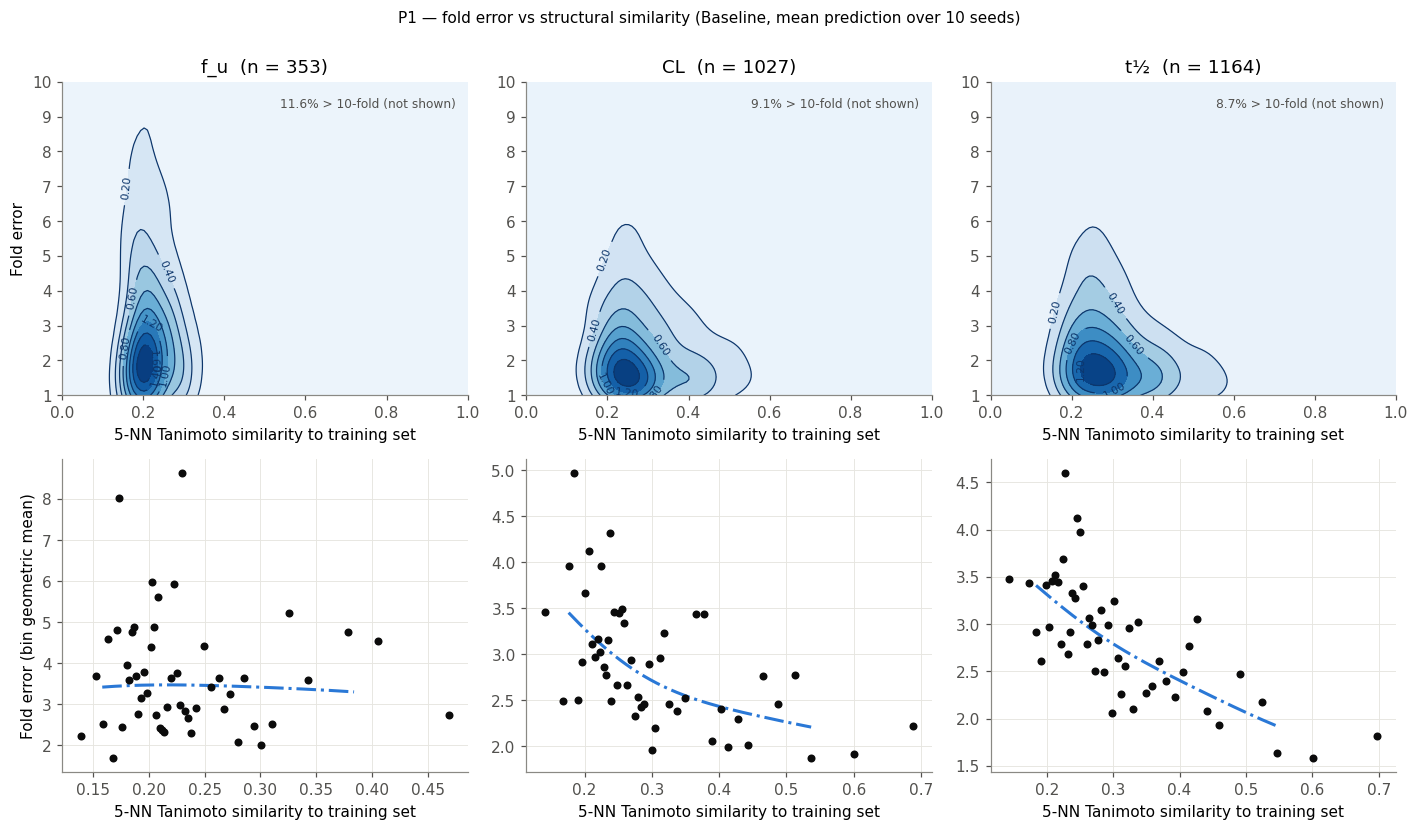

In [37]:
from scipy.stats import gaussian_kde
from sklearn.kernel_ridge import KernelRidge

if HAVE_PRED:
    fig, axes = plt.subplots(2, len(PROPS), figsize=(13, 7.5))
    for c, p in enumerate(PROPS):
        d = comp[(comp['property'] == p) & (comp['method'] == PLOT_METHOD)].dropna(subset=['knn5_sim'])
        x, y = d['knn5_sim'].to_numpy(), d['fold_error'].to_numpy()
        ymax = 10.0
        # Top: 2D KDE (1–10-fold range)
        ax = axes[0, c]
        keep = y <= ymax
        kde = gaussian_kde(np.vstack([x[keep], y[keep]]))
        gx, gy = np.meshgrid(np.linspace(0, 1, 120), np.linspace(1, ymax, 120))
        z = kde(np.vstack([gx.ravel(), gy.ravel()])).reshape(gx.shape)
        ax.contourf(gx, gy, z, levels=8, cmap='Blues')
        cs = ax.contour(gx, gy, z, levels=8, colors='#0d366b', linewidths=0.8)
        ax.clabel(cs, fontsize=7, fmt='%.2f')
        ax.set_xlim(0, 1)
        ax.set_ylim(1, ymax)
        ax.set_title(f'{LABEL[p]}  (n = {len(d)})')
        ax.text(0.97, 0.95, f'{100 * (~keep).mean():.1f}% > {ymax:.0f}-fold (not shown)', transform=ax.transAxes,
                ha='right', va='top', fontsize=8, color='#52514e')
        ax.set_xlabel('5-NN Tanimoto similarity to training set')
        ax.grid(False)
        # Bottom: quantile-bin means + kernel ridge
        ax = axes[1, c]
        bins = pd.qcut(d['knn5_sim'], q=min(50, len(d) // 6), duplicates='drop')
        logfe = np.log10(y)
        binned = (d.assign(logfe=np.log10(d['fold_error'])).groupby(bins, observed=True)
                   .agg(sim=('knn5_sim', 'mean'), logfe=('logfe', 'mean')))
        ax.scatter(binned['sim'], 10 ** binned['logfe'], s=18, color='#0b0b0b', zorder=3)
        kr = KernelRidge(kernel='rbf', alpha=1.0, gamma=10.0).fit(x[:, None], logfe)
        xs_ = np.linspace(*np.percentile(x, [5, 95]), 200)
        ax.plot(xs_, 10 ** kr.predict(xs_[:, None]), ls='-.', lw=2, color='#2a78d6')
        ax.set_xlabel('5-NN Tanimoto similarity to training set')
    axes[0, 0].set_ylabel('Fold error')
    axes[1, 0].set_ylabel('Fold error (bin geometric mean)')
    fig.suptitle(f'P1 — fold error vs structural similarity ({PLOT_METHOD}, mean prediction over 10 seeds)', fontsize=10, y=1.0)
    plt.tight_layout()
    plt.show()

#### P2. Predicted vs observed (per-compound 10-seed mean prediction)
log10 units. Dashed line = y = x. RMSE (mean predictor) = RMSE when every compound is predicted by the observed mean (reference).

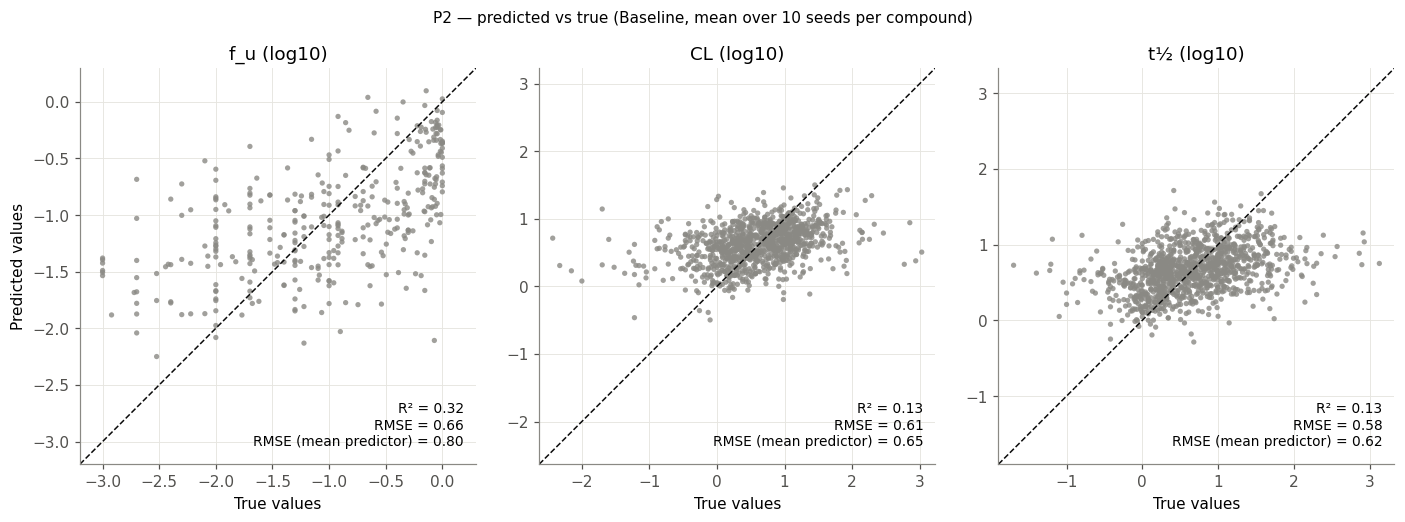

In [38]:
if HAVE_PRED:
    fig, axes = plt.subplots(1, len(PROPS), figsize=(13, 4.4))
    for ax, p in zip(axes, PROPS):
        d = comp[(comp['property'] == p) & (comp['method'] == PLOT_METHOD)]
        y, yp = d['true_log'].to_numpy(), d['pred_log'].to_numpy()
        r2 = 1 - ((y - yp) ** 2).sum() / ((y - y.mean()) ** 2).sum()
        rmse = np.sqrt(((y - yp) ** 2).mean())
        rmse0 = np.sqrt(((y - y.mean()) ** 2).mean())
        ax.scatter(y, yp, s=12, color='#8a8984', alpha=0.8, edgecolors='none')
        lo, hi = min(y.min(), yp.min()) - 0.2, max(y.max(), yp.max()) + 0.2
        ax.plot([lo, hi], [lo, hi], ls='--', lw=1, color='#0b0b0b')
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_aspect('equal')
        ax.text(0.97, 0.04, f'R² = {r2:.2f}\nRMSE = {rmse:.2f}\nRMSE (mean predictor) = {rmse0:.2f}',
                transform=ax.transAxes, ha='right', va='bottom', fontsize=9)
        ax.set_title(f'{LABEL[p]} (log10)')
        ax.set_xlabel('True values')
    axes[0].set_ylabel('Predicted values')
    fig.suptitle(f'P2 — predicted vs true ({PLOT_METHOD}, mean over 10 seeds per compound)', fontsize=10, y=1.02)
    plt.tight_layout()
    plt.show()

## 3.7 Caveats for interpretation

1. **Reference shifts with the number of seeds** — 08 uses 10 seeds, 09 and 10 use seeds 0–2. As the table below shows, the frozen R² depends on the seed set, so always compare within the same seeds.
2. **Label-transfer gain on t½** — zero-shot ρ ≈ 0, yet R² rises after fine-tuning. Separating label information from extra representation learning needs a **pretraining control with shuffled source labels**.
3. **Power** — paired tests over 5 folds. Run-to-run SD is large relative to the effect size (ΔR² 0.01–0.1).
4. Excluded from the paper: benchmark phase 06/07 composite scores (arbitrary weights), phase 08/09 (old data), `mmd_domain_adaptation.py` (early stopping on test).

In [39]:
pd.DataFrame({LABEL[p]: {
    'frozen R² (10 seeds)': base[base['property'] == p]['r2'].mean(),
    'frozen R² (seed 0–2)': frozen3[frozen3['property'] == p]['r2'].mean(),
    'seed-to-seed SD of 5-fold R²': per_seed.loc[p]['r2'].std(),
    'pretrain→FT run SD of R²': pre[pre['property'] == p]['r2'].std(),
} for p in PROPS}).round(4)

,f_u,CL,t½
frozen R² (10 seeds),0.2522,0.0969,0.0838
frozen R² (seed 0–2),0.2485,0.0999,0.1067
seed-to-seed SD of 5-fold R²,0.0201,0.0139,0.0241
pretrain→FT run SD of R²,0.1440,0.0618,0.1047
